# QHD solution quality: refinement and nonlinear constraints

Zeguan Wu and coauthors test quantum Hamiltonian descent (QHD) with box refinement and an augmented-Lagrangian (AL) outer loop ([arXiv:2605.12066v1](https://arxiv.org/abs/2605.12066v1), Sec. VI). On smaller grids, this notebook asks whether refinement finds the narrow minimum of a shifted Ackley function and whether the AL loop finds a constrained Rastrigin basin.

As in the paper, the optimization runs are classical evolutions of the grid model with exact probabilities, and Section 6 runs one 4-qubit circuit of the same construction.

Install with `python -m pip install -e ".[aer,notebook]"` from the repository root · 8- and 10-qubit models evolved classically, one 4-qubit circuit simulated · about 65 s on a laptop.

> **How to read this notebook.** The next cells solve Ackley and show the answer with its cost.
>
> - Sections 1 to 4: Ackley against L-BFGS-B, constrained Rastrigin against SLSQP, shots, the conclusion
> - Sections 5 to 9: will it run, what it costs, how accurate, how large, what it assumes
> - Section 10: your own objective
> - Section 11: the paper's problems, the model, and how the settings differ from the paper
> - Appendix A to E: every level and round, the restarts, an independent circuit check, the time-step and larger studies

In [1]:
from time import perf_counter

import numpy as np
import sympy as sp
from sympy.codegen.cfunctions import expm1

from nwqlib import Optimization
from nwqlib.algorithms.qhd import QHD, BoxRefinement, QuadraticSchedule, refine_box

x, y = sp.symbols("x y", real=True)
BOX = ((-5.0, 5.0), (-5.0, 5.0))                 # the paper's domain
# Full binary64 shift used by this example, reconstructed from the authors'
# seeded shift procedure. The manuscript prints rounded coordinates.
SHIFT = (0.961528396769231, 0.3696594771697266)  # the shifted minimizer x*, where f = 0 (Sec. VI.A)
z1, z2 = x - sp.Rational(SHIFT[0]), y - sp.Rational(SHIFT[1])  # exact rationals of the binary64 shift
# The paper's Eq. (16) for two variables, written with expm1 to avoid subtracting nearly equal constants
# (Section 11).
ACKLEY = (-20 * expm1(-sp.sqrt((z1**2 + z2**2) / 2) / 5)
          - sp.E * expm1(-sp.sin(sp.pi * z1) ** 2 - sp.sin(sp.pi * z2) ** 2))

ackley_problem = Optimization(objective=ACKLEY, variables=(x, y), bounds=BOX)
qhd = QHD(encoding="binary", boundary="periodic", kinetic_model="spectral",  # the paper's Fourier grid model
          num_grid_points=16,                             # per variable: 4 qubits each, 256 grid points
          theory_flavor="split_step", num_steps=2048,     # symmetric split steps of the classical evolution
          total_time=10.0, schedule=QuadraticSchedule(gamma=0.3),
          keep_state=True)                                # keep every level's state for Section 3
refinement = BoxRefinement(max_levels=10, max_no_improve=10,  # ten levels on shrinking boxes, fixed before the run
                           potential_gain=8)                  # strength of the normalized potential, Section 11
started = perf_counter()
ackley = refine_box(ackley_problem, qhd=qhd, options=refinement, execution="classical", seed=7, progress=False)
ackley_seconds = perf_counter() - started

In [2]:
# Helpers of the result card and the tables: an independent NumPy evaluation of Ackley's function, the L-BFGS-B
# baseline, display helpers and the card itself. Nothing in this cell calls NWQLib.
from html import escape

import matplotlib.pyplot as plt
from IPython.display import HTML, display
from scipy.optimize import minimize

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
BLUE, VERMILION, GREEN, GRAY = "#0072B2", "#D55E00", "#009E73", "#777777"


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations keep full precision."""
    if value is None:
        return "none"
    if isinstance(value, (bool, np.bool_, str)):
        return str(value)
    if isinstance(value, (int, np.integer)):
        return f"{value:,}"
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}g}"
    if isinstance(value, (tuple, list, np.ndarray)):
        return "(" + ", ".join(format_value(item, digits) for item in value) + ")"
    return str(value)


def show_table(rows, headers=("Quantity", "Value", "Meaning"), *, digits=3, details=None):
    """Display rows of computed values, optionally collapsed under a summary line."""
    body = "".join("<tr>" + "".join('<td style="text-align:left">' + escape(format_value(value, digits)) + "</td>"
                                    for value in row) + "</tr>" for row in rows)
    table = ("<table><thead><tr>" + "".join("<th>" + escape(label) + "</th>" for label in headers)
             + "</tr></thead><tbody>" + body + "</tbody></table>")
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def ackley_value(points):
    """Ackley's function at points of shape (..., 2), from its formula, independently of the SymPy input."""
    z = np.asarray(points, dtype=float) - np.asarray(SHIFT)
    return (-20 * np.expm1(-0.2 * np.sqrt(np.mean(z * z, axis=-1)))
            - np.e * np.expm1(-np.sum(np.sin(np.pi * z) ** 2, axis=-1)))


def distance(point, reference):
    """Euclidean distance of a returned point from a known minimizer."""
    return float(np.linalg.norm(np.asarray(point, dtype=float) - np.asarray(reference)))


def incumbents(levels, value, reference):
    """Objective and distance of the best point found up to each completed level."""
    best, rows = None, []
    for level in levels:
        if best is None or value(level.point) < value(best):
            best = level.point
        rows.append((float(value(best)), distance(best, reference)))
    return np.array(rows)


# The same 100 starts, uniform on the box, as the authors' experiment scripts, RandomState(0).
RESTART_STARTS = np.random.RandomState(0).uniform(-5.0, 5.0, (100, 2))


def lbfgsb_restarts():
    """100-start L-BFGS-B on Ackley at each tolerance ftol of the authors' experiment scripts, 400 local solves."""
    rows = []
    for ftol in (1e-10, 1e-16, 1e-20, 1e-24):
        started = perf_counter()
        runs = [minimize(ackley_value, start, method="L-BFGS-B", bounds=BOX, options={"ftol": ftol})
                for start in RESTART_STARTS]
        best = min(runs, key=lambda run: ackley_value(run.x))
        rows.append(dict(ftol=ftol, best=best, objective=float(ackley_value(best.x)), distance=distance(best.x, SHIFT),
                         successes=sum(bool(run.success) for run in runs), nfev=sum(run.nfev for run in runs),
                         seconds=perf_counter() - started))
    return rows


def show_ackley_card(result, control, lbfgsb, targets, seconds):
    """Show the result card: the answer against the targets, the baseline with its budget, the cost of both
    ledgers, the refinement figure, what NWQLib did and, collapsed, the gain-1 control."""
    level = result.levels[0]
    grid = result.qhd.num_grid_points
    error = distance(result.candidate, SHIFT)
    met = result.objective <= targets["objective"] and error <= targets["distance"]
    classical = min(lbfgsb, key=lambda row: row["objective"])
    runs = len(lbfgsb) * len(RESTART_STARTS)
    calls = sum(row["nfev"] for row in lbfgsb)
    display(HTML(
        f"<p><strong>Result.</strong> After {len(result.levels)} refinement levels, the selected point has objective "
        f"{result.objective:.2g} and distance {error:.2g} from the known minimizer x*. It "
        f"{'meets' if met else 'misses'} the targets f ≤ {targets['objective']:g} and distance ≤ "
        f"{targets['distance']:g}, fixed before the run. Execution: classical evolution of the {grid} × {grid} grid "
        f"model with exact probabilities. Output: <code>ackley.candidate</code>, a point in the original "
        f"coordinates, and <code>ackley.objective</code>, its objective.</p>"
        f"<p><strong>Baseline.</strong> L-BFGS-B from {len(RESTART_STARTS)} random starts at each of {len(lbfgsb)} "
        f"tolerances, {runs} local solves and {calls:,} objective calls in "
        f"{sum(row['seconds'] for row in lbfgsb):.2f} s, reaches {classical['objective']:.3g}, "
        f"{'lower' if classical['objective'] < result.objective else 'higher'} than this run.</p>"
        f"<p><strong>Cost.</strong> Quantum: the runs prepared {result.resources.circuit_preparations} "
        f"circuits and took {result.resources.shots} shots. On a quantum computer each of the {len(result.levels)} "
        f"solves would be one {level.logical_width}-qubit circuit plus its shots (Section 3). Classical: known host "
        f"workspace {max(run.plan.reconstruction.workspace_bytes for run in result.results):,} bytes per solve, "
        f"stated by the plan before it runs, evolution work {result.resources.evolution_work:,} units over the "
        f"{len(result.levels)} solves (a planning quantity, not seconds), each solve within max_work = "
        f"{result.qhd.max_work:,}, {seconds:.1f} s on this computer.</p>"))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), layout="constrained")
    for run, label, color, marker in ((control, "Gain 1", GRAY, "s"), (result, "Gain 8", BLUE, "o")):
        best = incumbents(run.levels, ackley_value, SHIFT)
        levels = np.arange(1, len(best) + 1)
        axes[0].semilogy(levels, best[:, 0], marker=marker, markersize=4, color=color, label=label)
        axes[1].semilogy(levels, best[:, 1], marker=marker, markersize=4, color=color, label=label)
    for ax, key, target in ((axes[0], "objective", targets["objective"]), (axes[1], "distance", targets["distance"])):
        ax.axhline(classical[key], linestyle="--", color=GREEN, label=f"L-BFGS-B, best of {runs} runs")
        ax.axhline(target, linestyle=":", color="black", label="Target")
        ax.set(xlabel="Completed refinement level", xticks=range(1, len(result.levels) + 1))
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(alpha=0.2)
    axes[0].set(ylabel="Best objective so far", title="(a) Ackley objective")
    axes[1].set(ylabel="Distance to the minimizer x*", title="(b) Ackley position")
    plt.show()

    steps = (
        f"On each level's box, tabulated the objective on the {grid} × {grid} grid of the unit square, normalized "
        f"it to lie between 0 and 1 on the grid and multiplied it by the gain {level.potential_gain:g}, so every "
        f"level solves a dimensionless problem of the same strength (the search model, Section 11).",
        f"Evolved the {grid * grid} grid amplitudes numerically through {result.qhd.num_steps:,} symmetric split steps "
        f"of the QHD Hamiltonian and read out the most probable grid point. A binary circuit of this construction with "
        f"{level.logical_width} qubits realizes the same product, with additional angle-formation and lowering errors "
        f"(Section 6).",
        f"Kept, for each variable, the grid cells around the peak of its probability that hold "
        f"{result.options.mass_threshold:.0%} of it, took their product as the next box, and selected the completed "
        f"level with the least recorded relative objective, with earlier levels winning ties.",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in steps) + "</ol>"))
    display(HTML(
        f"<details><summary>The gain-1 control and the paper's comparison</summary><p>The refinement used a budget "
        f"of {result.options.max_levels} levels, fixed before the run. With the gain, the strength of the normalized "
        f"potential, set to 1 instead of {level.potential_gain:g}, the same refinement ends at objective "
        f"{control.objective:.2g}. In the paper's Table I the refinement on a 32 × 32 grid falls below the paper's "
        f"L-BFGS-B value, 4.17e-09, at 13 levels and not at 7.</p></details>"
        "<p>Section 10 has a cell for your own objective.</p>"))

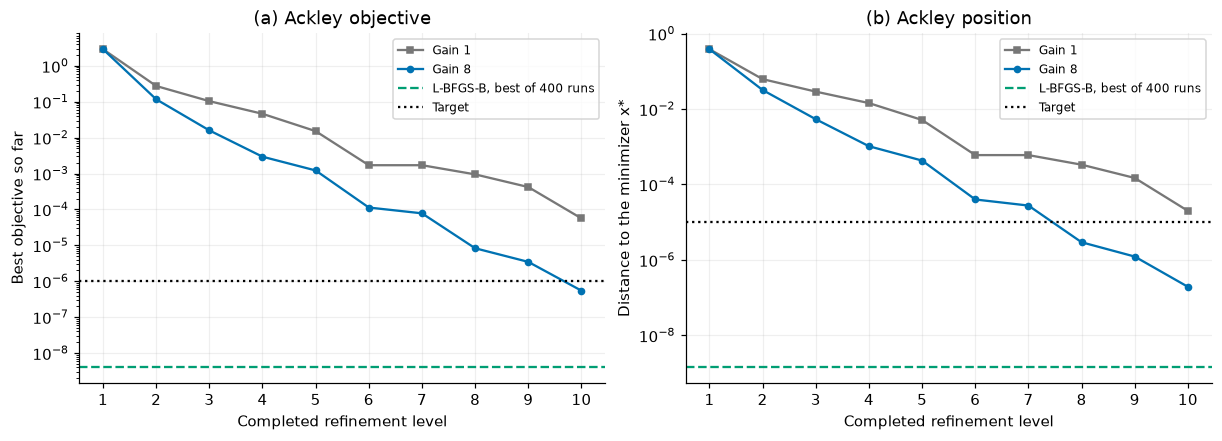

In [3]:
# Targets for judging the answer, chosen before the runs. The known minimizer x* is used only to evaluate.
ACKLEY_TARGETS = {"objective": 1e-6, "distance": 1e-5}
# The same refinement with gain 1, and 100-start L-BFGS-B at four tolerances (Section 1), about 2 s together.
started = perf_counter()
ackley_gain1 = refine_box(ackley_problem, qhd=qhd, options=refinement.revise(potential_gain=1),
                          execution="classical", seed=7, progress=False)
ackley_gain1_seconds = perf_counter() - started
lbfgsb = lbfgsb_restarts()
show_ackley_card(ackley, ackley_gain1, lbfgsb, ACKLEY_TARGETS, ackley_seconds)

**Figure 1** shows the best objective found up to each completed level and that point's distance to $x^*$, for the gains 8 and 1. The best L-BFGS-B point and the targets are horizontal lines.

For inequality constraints, Section 2 passes a `ConstrainedOptimization` problem and `AugmentedLagrangian` options with the same QHD settings. [Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## 1. Ackley: precision from refinement on a fixed grid

**Refinement shrinks the box at every level while the register keeps its 8 qubits, so the grid spacing falls with the box.** On the first level the spacing is $10/16=0.625$.

Each level shrinks the box to the cells that hold 99% of each variable's probability. The threshold applies to each variable separately, so the joint probability of the next box can be lower than 0.99. Appendix A lists it for every level.

The table lists each gain-8 level with the objective and distance of its point, evaluated with NumPy from the returned coordinates. The objective target $10^{-6}$ is the order of tolerance that the paper calls often sufficient for power-system problems (Sec. VI.A).

In [4]:
show_table([(level.level, (level.box[0][1] - level.box[0][0], level.box[1][1] - level.box[1][0]),
             level.point_probability, ackley_value(level.point), distance(level.point, SHIFT))
            for level in ackley.levels],
           headers=("Level", "Box widths (x, y)", "Probability of the point", "Objective", "Distance to x*"))

Level,"Box widths (x, y)",Probability of the point,Objective,Distance to x*
1,"(10, 10)",0.435,2.91,0.385
2,"(2.5, 1.88)",0.8,0.117,0.0319
3,"(0.469, 0.352)",0.423,0.0159,0.00536
4,"(0.0879, 0.0879)",0.44,0.00295,0.00103
5,"(0.022, 0.022)",0.453,0.00122,0.00043
6,"(0.00412, 0.00549)",0.626,0.000113,4e-05
7,"(0.000772, 0.00103)",0.448,7.8e-05,2.76e-05
8,"(0.000145, 0.000193)",0.551,8.31e-06,2.94e-06
9,"(2.72e-05, 3.62e-05)",0.298,3.46e-06,1.22e-06
10,"(6.79e-06, 9.05e-06)",0.529,5.47e-07,1.93e-07


L-BFGS-B starts from the 100 random points of the authors' experiment scripts at each of the four tolerances of those scripts. The table also gives the solver status of the best run, because a run can return an accurate point without meeting its own stopping test.

In [5]:
show_table([(row["ftol"], row["objective"], row["distance"], row["successes"], row["nfev"],
             f"success={row['best'].success}, status {row['best'].status}")
            for row in lbfgsb],
           headers=("ftol", "Best objective", "Its distance to x*", "Runs reporting success", "Objective calls",
                    "Status of the best run"))

ftol,Best objective,Its distance to x*,Runs reporting success,Objective calls,Status of the best run
1e-10,4.15e-09,1.47e-09,96,"6,396","success=False, status 2"
1e-16,4.15e-09,1.47e-09,93,"6,897","success=False, status 2"
1e-20,4.15e-09,1.47e-09,93,"6,897","success=False, status 2"
1e-24,4.15e-09,1.47e-09,93,"6,897","success=False, status 2"


The paper's Table I reports the refinement on a 32 × 32 grid with 50,000 time points and the shifted cubic schedule, and a 100-start L-BFGS-B objective of 4.17 × 10⁻⁹. These are published values, not runs of this notebook.

In the paper's form the objective is a difference of numbers near $20+e\approx22.7$, whose binary64 spacing is $3.6\times10^{-15}$. The last row's objective is therefore about one rounding unit.

| Levels Z | Objective | Distance to x* |
| --- | --- | --- |
| 1 | 2.74 × 10⁻¹ | 6.19 × 10⁻² |
| 7 | 9.59 × 10⁻⁶ | 3.39 × 10⁻⁶ |
| 13 | 2.21 × 10⁻¹⁰ | 7.82 × 10⁻¹¹ |
| 19 | 4.00 × 10⁻¹⁵ | 9.16 × 10⁻¹⁶ |

## 2. Constrained Rastrigin: refinement inside every AL round

**The AL loop refines the box of an augmented objective in every round, and the runs differ only in $Z$, the number of refinement levels per round.** Section 11 states the problem, the AL update and its stopping test.

Every round starts from the full box. With $Z=1$ each round therefore solves one 32 × 32 grid of spacing $10/32\approx0.31$, coarse against the Rastrigin oscillations of period 1/3. SLSQP starts from the same 100 random points of the authors' experiment scripts.

The targets were fixed before the runs. At a distance $r$ from the optimum, $f-f^*$ is about $\tfrac12q''(t^*)\,r^2$ with $q''(t^*)\approx3.6\times10^3$.

The distance 0.01 therefore corresponds to a gap of about 0.18, so the gap target 0.2 and the distance target 0.01 ask for about the same accuracy, far inside the basin.

After the collapsed helpers, one cell defines the problem and computes the known optimum for the evaluation. The next runs the three AL runs and SLSQP, in about 55 s.

In [6]:
# Helpers for the constrained comparison: independent NumPy evaluations of the problem, the SLSQP baseline, a
# summary of one AL run, its figure and the sentences computed from the runs. Nothing in this cell calls NWQLib.
def rastrigin_value(points):
    """The scaled Rastrigin function of the paper's Eq. (17) with alpha = 3, at points of shape (..., 2)."""
    points = np.asarray(points, dtype=float)
    return 20 + np.sum(9 * points * points - 10 * np.cos(6 * np.pi * points), axis=-1)


def constraint_values(points):
    """The constraints g1 and g2 of the paper's Eq. (18), feasible where g <= 0, at points of shape (..., 2).

    The coefficient 0.02 is written as in the paper's Eq. (18). The SymPy input uses the exact 1/50, and the two
    differ only by rounding.
    """
    points = np.asarray(points, dtype=float)
    first, second = points[..., 0], points[..., 1]
    return np.stack((0.5 - first + 0.02 * (second - 0.5) ** 2, 0.5 - second + 0.02 * (first - 0.5) ** 2), axis=-1)


def slsqp_restarts(tolerance):
    """100-start SLSQP on constrained Rastrigin with the scripts' ftol 1e-16 and at most 500 iterations."""
    started = perf_counter()
    constraints = [{"type": "ineq", "fun": lambda point, j=j: -constraint_values(point)[j]} for j in range(2)]
    runs = [minimize(rastrigin_value, start, method="SLSQP", bounds=BOX, constraints=constraints,
                     options={"ftol": 1e-16, "maxiter": 500}) for start in RESTART_STARTS]
    feasible = [run for run in runs if constraint_values(run.x).max() <= tolerance]
    best = min(feasible, key=lambda run: rastrigin_value(run.x))
    return dict(best=best, objective=float(rastrigin_value(best.x)), runs=runs, feasible=len(feasible),
                successes=sum(bool(run.success) for run in runs), nfev=sum(run.nfev for run in runs),
                seconds=perf_counter() - started)


def al_summary(run, tolerance):
    """Best feasible outer point of an AL run, its quality against the known optimum, and the run's size."""
    feasible = [item for item in run.iterations
                if item.evaluation is not None and constraint_values(item.evaluation.point).max() <= tolerance]
    best = min(feasible, key=lambda item: rastrigin_value(item.evaluation.point)) if feasible else None
    point = None if best is None else np.asarray(best.evaluation.point)
    value = None if best is None else float(rastrigin_value(point))
    return dict(
        point=point, objective=value, gap=None if best is None else value - F_STAR,
        distance=None if best is None else distance(point, X_STAR),
        residuals=None if best is None else constraint_values(point),
        best_round=None if best is None else best.iteration + 1,
        rounds=len(run.iterations), solves=sum(len(item.refinement.levels) for item in run.iterations),
        stop=run.termination, largest_penalty=max(item.penalty for item in run.iterations))


def listing(names):
    """Names joined as 'A', 'A and B' or 'A, B and C'."""
    return names[0] if len(names) == 1 else ", ".join(names[:-1]) + " and " + names[-1]


def meets(summary, targets):
    """Whether a run's best feasible point meets both the gap and the distance target."""
    return summary["gap"] is not None and summary["gap"] <= targets["gap"] and summary["distance"] <= targets["distance"]


def show_al_figure(runs, slsqp, tolerance, targets):
    """(a) the objective at every round's point, (b) the gap of the feasible ones, (c) the residuals of the run
    with the most levels per round."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.9), layout="constrained")
    styles = dict(zip(sorted(runs), ((GRAY, "s", -0.12), (VERMILION, "^", 0.0), (BLUE, "o", 0.12))))
    for levels, run in runs.items():
        color, marker, offset = styles[levels]
        rounds = np.arange(1, len(run.iterations) + 1)
        values = np.array([item.evaluation.objective for item in run.iterations])
        feasible = np.array([item.evaluation.infeasibility <= tolerance for item in run.iterations])
        axes[0].plot(rounds, values, color=color, linewidth=0.8, alpha=0.6)
        axes[0].scatter(rounds[feasible], values[feasible], color=color, marker=marker, s=28, label=f"Z = {levels}")
        axes[0].scatter(rounds[~feasible], values[~feasible], color=color, marker="x", s=30)
        # Points of different Z are offset slightly along the round axis, so that equal gaps stay visible.
        axes[1].scatter(rounds[feasible] + offset, values[feasible] - F_STAR, color=color, marker=marker, s=28,
                        label=f"Z = {levels}")
    axes[0].scatter([], [], color="black", marker="x", s=30, label="Infeasible point")
    axes[0].axhline(slsqp["objective"], linestyle="--", color=GREEN, label="SLSQP, best of 100 starts")
    axes[0].axhline(F_STAR, linestyle=":", color="black", label="Constrained optimum f*")
    axes[0].set(xlabel="AL round", ylabel="Objective f at the round's point", title="(a) Rastrigin outer points",
                ylim=(-0.5, 17.5))
    axes[0].legend(fontsize=8, loc="upper left", ncol=2)
    axes[1].axhline(slsqp["objective"] - F_STAR, linestyle="--", color=GREEN, label="SLSQP, best of 100 starts")
    axes[1].axhline(targets["gap"], linestyle=":", color="black", label="Gap target")
    axes[1].set(yscale="log", xlabel="AL round", ylabel="Gap f − f* of a feasible point",
                title="(b) Feasible points, gap to f*")
    axes[1].legend(fontsize=8, loc="center left")
    last = runs[max(runs)]
    rounds = np.arange(1, len(last.iterations) + 1)
    for key, label, color, marker in (("infeasibility", "Violation", BLUE, "o"),
                                      ("complementarity", "Complementarity", VERMILION, "s")):
        axes[2].plot(rounds, [getattr(item.evaluation, key) for item in last.iterations],
                     marker=marker, markersize=4, color=color, label=label)
    axes[2].axhline(tolerance, linestyle=":", color="black", label="Tolerance")
    axes[2].set_yscale("symlog", linthresh=tolerance)
    axes[2].set(xlabel="AL round", ylabel="Normalized residual", title=f"(c) Rastrigin residuals, Z = {max(runs)}",
                ylim=(0, 1))
    axes[2].legend(fontsize=8, loc="center left")
    for ax in axes:
        ax.set_xticks(range(1, max(len(run.iterations) for run in runs.values()) + 1))
        ax.grid(alpha=0.2)
    plt.show()


def show_al_verdict(summaries, targets, options):
    """The sentences under the comparison table, computed from the runs."""
    stops = sorted({summary["stop"] for summary in summaries.values()})
    missed = [str(levels) for levels, summary in summaries.items() if not meets(summary, targets)]
    text = f"The runs stop with status <code>{'</code>, <code>'.join(stops)}</code>. "
    if missed:
        text += (f"The runs with Z = {listing(missed)} miss the gap or distance target despite their stop, so a "
                 f"stop label says that the residual tests passed and nothing about the objective. ")
    else:
        text += "Every run meets both targets. "
    largest = max(summary["largest_penalty"] for summary in summaries.values())
    text += (f"The largest penalty any round enters with is {largest:g}, "
             f"{'below' if largest < options.max_penalty else 'at'} the ceiling {options.max_penalty:g}. The stop "
             f"does not test the projected stationarity, which Appendix B lists for every round, so it does not "
             f"certify a stationary point either. The known optimum has inactive constraints, "
             f"g = {constraint_values(X_STAR)[0]:.3g}.")
    display(HTML("<p>" + text + "</p>"))

In [7]:
from scipy.optimize import brentq

from nwqlib import ConstrainedOptimization
from nwqlib.algorithms.qhd import AugmentedLagrangian, solve_augmented_lagrangian

# The paper's scaled Rastrigin function, Eq. (17) with alpha = 3, and its constraints, Eq. (18), as g <= 0.
RASTRIGIN = 20 + 9 * (x**2 + y**2) - 10 * sp.cos(6 * sp.pi * x) - 10 * sp.cos(6 * sp.pi * y)
CONSTRAINTS = (sp.Rational(1, 2) - x + (y - sp.Rational(1, 2)) ** 2 / 50,
               sp.Rational(1, 2) - y + (x - sp.Rational(1, 2)) ** 2 / 50)
rastrigin_problem = ConstrainedOptimization(objective=RASTRIGIN, variables=(x, y), bounds=BOX,
                                            inequalities=CONSTRAINTS)
rastrigin_qhd = qhd.revise(num_grid_points=32, num_steps=8192)  # 5 qubits per variable, 1,024 grid points
al_options = AugmentedLagrangian(max_iterations=15, max_penalty=1024.0,  # a ceiling on the penalty, Section 11
                                 feasibility_tolerance=1e-9, complementarity_tolerance=1e-9, stationarity=True)
LEVELS_PER_ROUND = (1, 3, 4)  # Z, the refinement levels in each round

# The known constrained optimum (t*, t*), used only to evaluate results (Section 11).
T_STAR = brentq(lambda t: 18 * t + 60 * np.pi * np.sin(6 * np.pi * t), 5 / 8, 2 / 3, xtol=5e-16)
X_STAR = np.array([T_STAR, T_STAR])
F_STAR = float(rastrigin_value(X_STAR))
RASTRIGIN_TARGETS = {"gap": 0.2, "distance": 0.01}

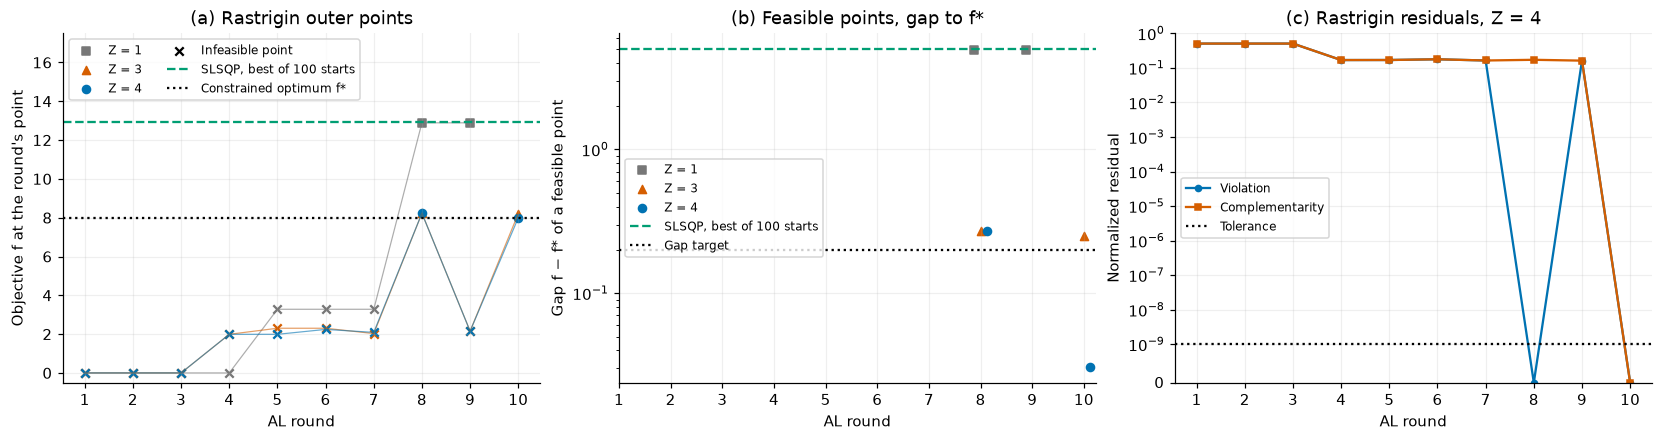

In [8]:
rastrigin_runs, rastrigin_seconds = {}, {}
for levels in LEVELS_PER_ROUND:
    started = perf_counter()
    rastrigin_runs[levels] = solve_augmented_lagrangian(
        rastrigin_problem, qhd=rastrigin_qhd, options=al_options,
        refinement=refinement.revise(max_levels=levels, max_no_improve=levels),
        execution="classical", seed=7, progress=False)
    rastrigin_seconds[levels] = perf_counter() - started
slsqp = slsqp_restarts(al_options.feasibility_tolerance)
summaries = {levels: al_summary(run, al_options.feasibility_tolerance) for levels, run in rastrigin_runs.items()}
show_al_figure(rastrigin_runs, slsqp, al_options.feasibility_tolerance, RASTRIGIN_TARGETS)

**Figure 2.** (a) The original objective at the point of every AL round. Filled markers are feasible points, and crosses violate a constraint, so their low objective does not compete with feasible ones.

(b) The gap $f-f^*$ of the feasible round points on a logarithmic axis, with the gap target and the gap of the best SLSQP point. Points of different $Z$ are offset slightly along the round axis.

(c) The normalized violation and complementarity of the run with the most levels per round, on an axis that is linear below $10^{-9}$ so that exact zeros are visible. All QHD points come from classical evolution with exact probabilities.

The table compares the best feasible point of each run with SLSQP, the known optimum and the paper's published result on a 64 × 64 grid. The gap and the distance are measured from $f^*$ and $x^*$, and $g_1, g_2$ are evaluated with NumPy at the returned point.

In [9]:
rows = [(f"QHD, Z = {levels}", summary["objective"], summary["gap"],
         None if summary["gap"] is None else summary["gap"] / F_STAR, summary["distance"], summary["residuals"],
         f"{summary['rounds']} / {summary['solves']}", summary["stop"], rastrigin_seconds[levels])
        for levels, summary in summaries.items()]
slsqp_point = slsqp["best"].x
rows += [
    ("SLSQP, best of 100 starts", slsqp["objective"], slsqp["objective"] - F_STAR,
     (slsqp["objective"] - F_STAR) / F_STAR, distance(slsqp_point, X_STAR), constraint_values(slsqp_point),
     f"{len(slsqp['runs'])} local solves, {slsqp['nfev']:,} objective calls",
     f"best run success={slsqp['best'].success}", slsqp["seconds"]),
    ("Known optimum (t*, t*)", F_STAR, 0.0, 0.0, 0.0, constraint_values(X_STAR), None, None, None),
    ("Paper, Z = 3 and 4, 64 × 64 (Table II)", 8.089, 8.089 - F_STAR, (8.089 - F_STAR) / F_STAR, 8.52e-3,
     "reported feasible", "6 rounds", "published, not run here", None),
]
show_table(rows, headers=("Configuration", "Best feasible f", "Gap f − f*", "Relative gap", "Distance to x*",
                          "g1, g2 at the point", "Rounds / QHD solves", "Stop", "Time [s]"), digits=4)
show_al_verdict(summaries, RASTRIGIN_TARGETS, al_options)

Configuration,Best feasible f,Gap f − f*,Relative gap,Distance to x*,"g1, g2 at the point",Rounds / QHD solves,Stop,Time [s]
"QHD, Z = 1",12.89,4.929,0.6193,0.05417,"(-0.1247, -0.1247)",9 / 9,feasible_complementary,5.436
"QHD, Z = 3",8.21,0.2499,0.0314,0.01187,"(-0.1544, -0.1544)",10 / 30,feasible_complementary,18.25
"QHD, Z = 4",7.99,0.0308,0.003869,0.00416,"(-0.1598, -0.1598)",10 / 40,feasible_complementary,23.98
"SLSQP, best of 100 starts",12.93,4.975,0.625,0.3316,"(-0.4944, -0.1584)","100 local solves, 5,647 objective calls",best run success=True,0.2195
"Known optimum (t*, t*)",7.96,0,0,0,"(-0.1628, -0.1628)",none,none,none
"Paper, Z = 3 and 4, 64 × 64 (Table II)",8.089,0.1293,0.01625,0.00852,reported feasible,6 rounds,"published, not run here",none


In the paper's Table II the runs with Z = 1 and Z = 2 reach 12.89 and 10.65 on the 64 × 64 grid.

The paper's Table III shows that SLSQP recovers the optimum with 200 and with 500 random starts. The SLSQP row is therefore a budgeted baseline, and no row here establishes an advantage over classical optimization in general.

## 3. How many shots find a good point

**The runs above read exact probabilities and used no shots. On hardware each shot returns one grid point of the binary register.**

For a fixed state, such as the output of a fixed circuit, let $p$ be the unconditional probability of a specified success event. $S$ independent repetitions all miss it with probability $(1-p)^S$, so the probability of at least one success is $P_S=1-(1-p)^S$.

The table takes the state of the selected level of the Ackley run and of the Rastrigin run with the most levels per round.

Success is defined with the known optimum, as $f\le10^{-6}$ for Ackley. For Rastrigin it is a feasible point with $f-f^*$ at most 0.2, the gap target, or at most 0.01, a stricter event.

The uniform distribution on the same grid shows how much the evolution concentrated the probability, although this comparison gives the uniform distribution the refined box for free. The 1,000 shots are one multinomial draw from each state with a fixed seed, not shots of a circuit.

These probabilities are conditional on the exact-readout boxes and multipliers, which came from exact distributions. They are not the success probability of a run whose boxes and multipliers are chosen from finite shots.

In [10]:
# Helpers for the measurement budget: the state of a selected level, its success probability and the figure.
# Nothing in this cell calls NWQLib.
from fractions import Fraction
from itertools import product


def level_distribution(result, box, points_per_axis):
    """Normalized probabilities of a level's kept state and the original coordinates of its grid points.

    The periodic grid excludes the upper face, x_i = lower + (upper - lower) i / K. Each coordinate is evaluated
    exactly from the binary64 box and rounded once, the rule by which NWQLib reports a level's point. The state is
    stored in lexicographic grid order with variable 0 first, the order of itertools.product over the two axes.
    Dividing by the squared norm removes its floating-point drift from the probabilities.
    """
    state = np.asarray(result.data.artifact(result.artifact).array)
    probability = np.abs(state) ** 2
    axes = [[float(Fraction(lower) + (Fraction(upper) - Fraction(lower)) * Fraction(i, points_per_axis))
             for i in range(points_per_axis)] for lower, upper in box]
    return probability / probability.sum(), np.array(list(product(*axes)))


def selected_level(run):
    """The level record and Result of the best level of an AL run's best round."""
    best = run.iterations[run.record.best]
    index = best.refinement.best_level - 1
    return best.refinement.levels[index], run.results[run.record.best][index], best.iteration + 1


def at_least_one(p, shots):
    """P_S = 1 - (1 - p)^S, evaluated without cancellation for small p."""
    return -np.expm1(shots * np.log1p(-p)) if p < 1 else np.ones_like(np.asarray(shots, dtype=float))


def probability_text(p, one_shot):
    """P_S to three digits. Below 1 whenever one shot fails with positive probability, even where binary64 gives 1."""
    return "> 0.999999" if p > 0.999999 and one_shot < 1 else format_value(p)


def show_shot_figure(curves):
    """P_S against S for each state, with the uniform distribution on the same grid for comparison."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
    shots = np.unique(np.geomspace(1, 1000, 200).astype(int))
    for ax, name in zip(axes, dict.fromkeys(curve[0] for curve in curves)):
        for curve_name, event, one_shot, uniform in curves:
            if curve_name != name:
                continue
            ax.plot(shots, at_least_one(one_shot, shots), "-" if one_shot > 0 else ":",
                    color=BLUE if one_shot > 0 else VERMILION, label=f"QHD state, {event}, p = {one_shot:.3g}")
            if one_shot > 0:
                ax.plot(shots, at_least_one(uniform, shots), "--", color=GRAY, label=f"Uniform on the grid, {event}")
        ax.set(xscale="log", ylim=(-0.03, 1.04), xlabel="Independent shots S", ylabel="P(at least one success)",
               title=name)
        ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2))
        ax.grid(alpha=0.2)
    plt.show()

State,Success event,"One shot, p",Uniform on the same grid,P with 100 shots,"P with 1,000 shots","Successes in 1,000 shots",Best feasible f sampled
"Ackley, level 10",f ≤ 1e-06,0.529,0.00391,> 0.999999,> 0.999999,491,5.47e-07
"Rastrigin Z = 4, round 10, level 4","feasible, f − f* ≤ 0.2",0.217,0.00391,> 0.999999,> 0.999999,211,7.99
"Rastrigin Z = 4, round 10, level 4","feasible, f − f* ≤ 0.01",0,0,0,0,0,7.99


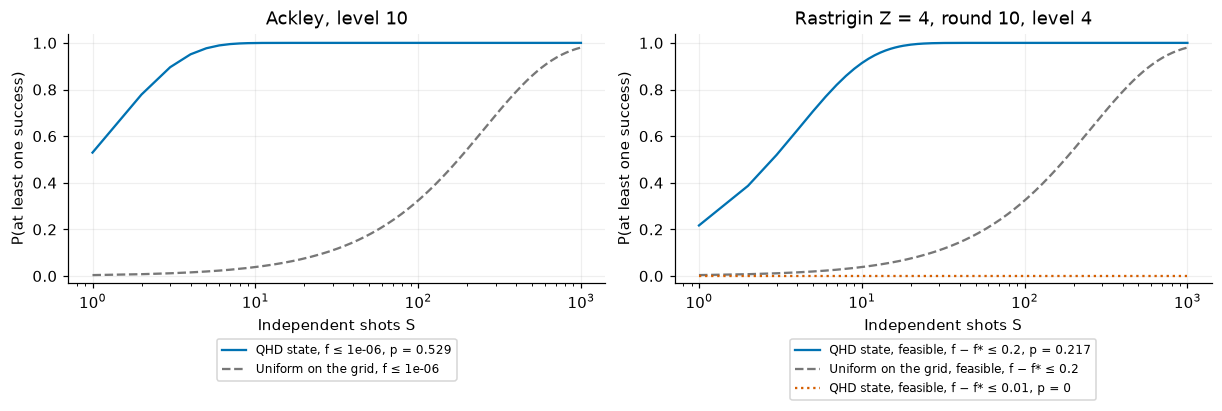

In [11]:
rng = np.random.default_rng(711)  # one fixed stream for the draws, Ackley first
ackley_level = ackley.levels[ackley.best_level - 1]
p_ackley, points_ackley = level_distribution(ackley.results[ackley.best_level - 1], ackley_level.box,
                                             qhd.num_grid_points)
f_ackley = ackley_value(points_ackley)
rastrigin_run = rastrigin_runs[max(LEVELS_PER_ROUND)]
rastrigin_level, rastrigin_result, rastrigin_round = selected_level(rastrigin_run)
p_rastrigin, points_rastrigin = level_distribution(rastrigin_result, rastrigin_level.box,
                                                   rastrigin_qhd.num_grid_points)
feasible_rastrigin = constraint_values(points_rastrigin).max(axis=-1) <= al_options.feasibility_tolerance
f_rastrigin = np.where(feasible_rastrigin, rastrigin_value(points_rastrigin), np.inf)  # infeasible never succeeds

shot_rows, curves = [], []
for name, p, f, reference, targets in (
        (f"Ackley, level {ackley_level.level}", p_ackley, f_ackley, 0.0, (ACKLEY_TARGETS["objective"],)),
        (f"Rastrigin Z = {max(LEVELS_PER_ROUND)}, round {rastrigin_round}, level {rastrigin_level.level}",
         p_rastrigin, f_rastrigin, F_STAR, (RASTRIGIN_TARGETS["gap"], 0.01))):
    counts = rng.multinomial(1000, p)  # one draw of 1,000 shots from this state
    for target in targets:
        success = f - reference <= target
        one_shot = float(p[success].sum())
        event = f"f ≤ {target:g}" if reference == 0.0 else f"feasible, f − f* ≤ {target:g}"
        shot_rows.append((name, event, one_shot, success.mean(),
                          probability_text(at_least_one(one_shot, 100), one_shot),
                          probability_text(at_least_one(one_shot, 1000), one_shot), int(counts[success].sum()),
                          f[counts > 0].min()))
        curves.append((name, event, one_shot, success.mean()))
show_table(shot_rows, headers=("State", "Success event", "One shot, p", "Uniform on the same grid",
                               "P with 100 shots", "P with 1,000 shots", "Successes in 1,000 shots",
                               "Best feasible f sampled"))
show_shot_figure(curves)

**Figure 3.** $P_S=1-(1-p)^S$ for the two selected states, conditional on the exact-readout boxes and multipliers. The success events are those of the table. A dotted line at zero marks an event that no point of the final grid meets.

When no feasible grid point of a state lies in a success event, no number of shots from that state reaches the event. The grid spacing of the last level sets that limit, and only a finer final grid, from more levels or more points per variable, moves it.

## 4. What these runs establish

**The conclusion below is computed from the runs, the known optima and the targets fixed before the runs.** A run meets its targets only when its best feasible point meets both the objective or gap target and the distance target. The stop status of a run is reported separately.

In [12]:
# The conclusion, computed from the runs, the known optima and the declared targets. Nothing in this cell calls
# NWQLib.
def run_names(entries):
    """'Ackley', 'Rastrigin with Z = 1 and 3' or both, for a list of ("Ackley", None) and ("Rastrigin", Z)."""
    parts = ["Ackley"] if ("Ackley", None) in entries else []
    levels = [str(z) for name, z in entries if name == "Rastrigin"]
    if levels:
        parts.append("Rastrigin with Z = " + listing(levels))
    return listing(parts)


def conclusion():
    """The lead sentence and one line per run, with the classical comparisons and their budgets."""
    ackley_error = distance(ackley.candidate, SHIFT)
    ackley_met = ackley.objective <= ACKLEY_TARGETS["objective"] and ackley_error <= ACKLEY_TARGETS["distance"]
    verdicts = [(("Ackley", None), ackley_met)] + [(("Rastrigin", levels), meets(summary, RASTRIGIN_TARGETS))
                                                   for levels, summary in summaries.items()]
    met = [entry for entry, ok in verdicts if ok]
    missed = [entry for entry, ok in verdicts if not ok]
    if not missed:
        lead = f"All {len(verdicts)} runs meet the declared targets."
    elif not met:
        lead = f"None of the {len(verdicts)} runs meets the declared targets."
    else:
        lead = (f"{run_names(met)} {'meets' if len(met) == 1 else 'meet'} the declared targets, and "
                f"{run_names(missed)} {'misses' if len(missed) == 1 else 'miss'} them.")
    lines = [f"Ackley, gain {refinement.gain:g}: objective {ackley.objective:.3g} at distance {ackley_error:.2g} "
             f"from x* after {len(ackley.levels)} solves of {qhd.num_steps:,} steps, stop {ackley.termination}. One "
             f"shot from the best level's state gives f ≤ {ACKLEY_TARGETS['objective']:g} with probability "
             f"{shot_rows[0][2]:.3g}."]
    for levels, summary in summaries.items():
        if summary["point"] is None:
            lines.append(f"Rastrigin, Z = {levels}: no feasible point was returned, so the gap to the optimum is "
                         f"unavailable. Stop {summary['stop']}.")
            continue
        line = (f"Rastrigin, Z = {levels}: best feasible objective {summary['objective']:.3g}, gap "
                f"{summary['gap']:.2g} to f* and distance {summary['distance']:.2g} to x*, after {summary['solves']} "
                f"solves of {rastrigin_qhd.num_steps:,} steps in {summary['rounds']} rounds, stop {summary['stop']}.")
        if levels == max(LEVELS_PER_ROUND):
            line += (f" One shot from the selected state gives a feasible f − f* ≤ {RASTRIGIN_TARGETS['gap']:g} with "
                     f"probability {shot_rows[1][2]:.3g}, and that state's grid has no feasible point with f − f* "
                     f"below {np.min(f_rastrigin) - F_STAR:.2g}, so no sample from that state comes closer.")
        lines.append(line)
    feasible = {levels: summary for levels, summary in summaries.items() if summary["objective"] is not None}
    if feasible:
        best = min(feasible, key=lambda levels: feasible[levels]["objective"])
        if feasible[best]["objective"] < slsqp["objective"]:
            lines.append(f"The best feasible QHD point, from Z = {best}, is lower than the best of "
                         f"{len(RESTART_STARTS)} SLSQP starts, {slsqp['objective']:.3g}, in this budgeted comparison "
                         f"({len(slsqp['runs'])} local solves, {slsqp['nfev']:,} objective calls).")
    classical = min(row["objective"] for row in lbfgsb)
    if classical < ackley.objective:
        lines.append(f"On Ackley the best L-BFGS-B point, {classical:.3g}, is more accurate than the refinement "
                     f"({len(lbfgsb) * len(RESTART_STARTS)} local solves, "
                     f"{sum(row['nfev'] for row in lbfgsb):,} objective calls).")
    return lead, lines

In [13]:
lead, lines = conclusion()
display(HTML(f"<p><strong>{escape(lead)}</strong></p><ul>"
             + "".join(f"<li>{escape(line)}</li>" for line in lines) + "</ul>"))

## 5. Will it run?

**Planning checks the work of every solve before any evolution, and a refusal names the limit and the amount to set.**

- **Input.** A real SymPy objective, its variables and one finite interval per variable. Constraints are written as `g <= 0` (Section 10).
- **Output.** A point in the original coordinates and its objective, read from exact probabilities here.
- **Size.** $d$ variables with $K$ grid points each use $d\log_2K$ qubits. The classical evolution stores $K^d$ amplitudes, and its charged work grows about as the number of steps times $K^d\log_2K$.
- **Limit.** `QHD(max_work=...)` caps the work of each solve. The default, 1,000,000,000, covers the 32 × 32 levels of Section 2.

The cell repeats the first Rastrigin call with `max_work` set to 100,000,000 for this demonstration (the default is 1,000,000,000). Planning refuses it before any evolution, and the message names the amount. The remedy is the default `max_work`, which the runs of Section 2 use.

In [14]:
DEMONSTRATION_MAX_WORK = 100_000_000  # below what one 32 × 32 level needs, to show the refusal
started = perf_counter()
try:
    solve_augmented_lagrangian(rastrigin_problem, qhd=rastrigin_qhd.revise(max_work=DEMONSTRATION_MAX_WORK),
                               options=al_options,
                               refinement=refinement.revise(max_levels=1, max_no_improve=1),
                               execution="classical", seed=7, progress=False)
except ValueError as refusal:
    print(f"Refused after {perf_counter() - started:.2f} s, before any evolution:\n{refusal}\n")
first_rastrigin_level = rastrigin_runs[min(LEVELS_PER_ROUND)].iterations[0].refinement.levels[0]
print(f"Remedy, the default of Section 2: max_work = {rastrigin_qhd.max_work:,}. Evolution work charged for one "
      f"32 × 32 level: {first_rastrigin_level.resources.evolution_work:,} units")

Refused after 0.06 s, before any evolution:
classical host evolution and readout requires 314178752 work units and 823808 bytes, with max_work=100000000 and max_bytes=10000000000. set QHD(max_work=314178752) or larger for this work charge. A smaller grid reduces explicit table and state dimensions. Replan to check all charges

Remedy, the default of Section 2: max_work = 1,000,000,000. Evolution work charged for one 32 × 32 level: 314,178,752 units


## 6. What it costs

**The optimization runs used host arithmetic only, so their quantum ledger is empty. On a quantum computer each solve would be one circuit of the listed width.**

The table counts the solves and their steps. Their evolution work counts host arithmetic, not quantum gates. A run on hardware would also need the shots of Section 3 for every solve.

In [15]:
cost_rows = [(f"Ackley, gain {run.levels[0].potential_gain:g}", len(run.levels), run.qhd.num_steps,
              len(run.levels) * run.qhd.num_steps, run.levels[0].logical_width,
              (run.resources.circuit_preparations, run.resources.shots),
              max(result.plan.reconstruction.workspace_bytes for result in run.results),
              run.resources.evolution_work, seconds)
             for run, seconds in ((ackley, ackley_seconds), (ackley_gain1, ackley_gain1_seconds))]
cost_rows += [(f"Rastrigin, Z = {levels}", summaries[levels]["solves"], rastrigin_qhd.num_steps,
               summaries[levels]["solves"] * rastrigin_qhd.num_steps, run.resources.width,
               (run.resources.circuit_preparations, run.resources.shots),
               max(result.plan.reconstruction.workspace_bytes for results in run.results for result in results),
               run.resources.evolution_work, rastrigin_seconds[levels])
              for levels, run in rastrigin_runs.items()]
show_table(cost_rows, headers=("Run", "QHD solves", "Steps per solve", "Evolution steps", "Qubits per circuit",
                               "Circuits prepared / shots", "Known host workspace per solve [bytes]",
                               "Evolution work units", "Time [s]"))

Run,QHD solves,Steps per solve,Evolution steps,Qubits per circuit,Circuits prepared / shots,Known host workspace per solve [bytes],Evolution work units,Time [s]
"Ackley, gain 8",10,"2,048","20,480",8,"(0, 0)","65,024","177,908,160",1.27
"Ackley, gain 1",10,"2,048","20,480",8,"(0, 0)","65,024","177,908,160",1.14
"Rastrigin, Z = 1",9,"8,192","73,728",10,"(0, 0)","187,392","2,827,608,768",5.44
"Rastrigin, Z = 3",30,"8,192","245,760",10,"(0, 0)","187,392","9,425,362,560",18.2
"Rastrigin, Z = 4",40,"8,192","327,680",10,"(0, 0)","187,392","12,567,150,080",24


- **Known host workspace** is the size of the buffers that the plan of each solve counts before it runs. It is not process memory.
- **Work units** are a planning quantity, not seconds. The time column is measured on this computer.
- **Not estimated:** physical qubits, error correction, run time on hardware and price.

**A 4-qubit circuit of the same construction.** `estimate` predicts the CX count and an upper bound on the arbitrary rotations from the resource laws of the selected construction, without building the circuit.

The cell plans one QHD solve of the Ackley objective itself on the original box, without refinement and the normalization of the search model, on a 4 × 4 binary grid with 8 steps and total time 0.5.

It then builds the circuit with `prepare`, compiles a copy to CX and single-qubit gates, and runs it once on the Aer statevector simulator. The same Method with `execution="classical"` gives the split-step state, and the two states are compared after aligning their global phase.

Qiskit stores variable 0 in the low-order qubits, so the circuit's amplitude of grid point $(n_0,n_1)$ sits at index $n_0+4n_1$. A transpose of its 4 × 4 view gives the lexicographic order of the classical state. Appendix D compares the circuit's state with an independent dense-matrix product.

In [16]:
from nwqlib import estimate, plan, prepare, solve, submit
from nwqlib.resources import ResourceContext

tiny_qhd = qhd.revise(num_grid_points=4, num_steps=8, total_time=0.5)
tiny_plan = plan(ackley_problem, method=tiny_qhd, execution="quantum", seed=7)  # plans, runs nothing
predicted = estimate(tiny_plan, context=ResourceContext(basis="cx"))           # resource laws, no circuit
# The CX law is stated in the cx basis and the rotation law in the default basis, so the full estimate reads both.
default_laws = {(item.metric, item.location): item for item in estimate(tiny_plan).quantities}
covered = [item if item.fact.availability == "concrete" else default_laws[item.metric, item.location]
           for item in predicted.quantities]
rotation_law = default_laws["arbitrary_rotations", None]
started = perf_counter()
prepared = prepare(tiny_plan, progress=False)
with prepared.run:  # the prepared Run holds the circuit until the block ends
    compiled = prepared.inspect_resources(
        transpile_options={"basis_gates": ["cx", "u"], "optimization_level": 0, "seed_transpiler": 7})
    native = submit(prepared).wait()
circuit_seconds = perf_counter() - started
circuit_state = np.asarray(native.data.artifact(native.artifact).array).reshape(4, 4).T.ravel()
classical_tiny = solve(ackley_problem, method=tiny_qhd, execution="classical", seed=7, progress=False)
classical_state = np.asarray(classical_tiny.data.artifact(classical_tiny.artifact).array)


def phase_aligned_difference(state, reference):
    """Distance of two states after removing their relative global phase, and the probability total variation."""
    overlap = np.vdot(reference, state)
    aligned = state * np.exp(-1j * np.angle(overlap))
    return np.linalg.norm(aligned - reference), 0.5 * np.abs(np.abs(state) ** 2 - np.abs(reference) ** 2).sum()


state_gap, probability_gap = phase_aligned_difference(circuit_state, classical_state)
predicted_cx = predicted.quantity("cx").fact.value.numerator
compiled_cx = compiled["operations"].get("cx", 0)
show_table([
    ("Qubits", predicted.quantity("logical_width", location="logical_device").fact.value.numerator,
     compiled["num_qubits"]),
    ("CX gates", f"{predicted_cx:,}, an upper bound", compiled_cx),
    ("Single-qubit gates", "not modeled", compiled["operations"].get("u", 0)),
    ("Arbitrary rotations", f"{rotation_law.fact.value.numerator:,}, "
     + ("an upper bound" if rotation_law.interpretation == "upper_bound" else rotation_law.interpretation),
     "not counted"),
    ("Depth", "not modeled", compiled["depth"]),
], headers=("Quantity", "Predicted by estimate", "Compiled, Qiskit level 0, seed 7"))
show_table([
    ("Circuit state − classical split-step state", state_gap, "Phase-aligned 2-norm"),
    ("Probability difference", probability_gap, "Total variation distance"),
    ("Circuit shots / native runs", (0, 1), "One exact statevector readout"),
    ("Prepare, compile and simulate [s]", circuit_seconds, "Simulator time, not a hardware time estimate"),
], digits=3)
display(HTML(
    f"<p>The predicted CX count sums the resource law of each block of the selected construction without building "
    f"the circuit. It is {'equal to' if predicted_cx == compiled_cx else f'{predicted_cx / compiled_cx:.3g} times'} "
    f"the compiled count at optimization level 0, before routing to a device's connectivity.</p>"))
show_table([(item.metric, item.fact.value.numerator, item.interpretation.replace("_", " "))
            for item in covered if item.fact.availability == "concrete"],
           headers=("Metric", "Value", "Kind"), details="Full resource estimate of the 4-qubit plan")
display(HTML("<p>Not covered by the resource laws of this construction: "
             + escape(", ".join(item.metric for item in covered if item.fact.availability != "concrete"))
             + ".</p>"))

Quantity,Predicted by estimate,"Compiled, Qiskit level 0, seed 7"
Qubits,4,4
CX gates,"320, an upper bound",320
Single-qubit gates,not modeled,452
Arbitrary rotations,"384, an upper bound",not counted
Depth,not modeled,493


Quantity,Value,Meaning
Circuit state − classical split-step state,1.66e-15,Phase-aligned 2-norm
Probability difference,8.99e-16,Total variation distance
Circuit shots / native runs,"(0, 1)",One exact statevector readout
"Prepare, compile and simulate [s]",0.699,"Simulator time, not a hardware time estimate"


Metric,Value,Kind
arbitrary_rotations,384,upper bound
cx,320,upper bound
calls,1,exact
measurements,0,exact
resets,0,exact
settings,1,exact
shots,0,exact
exact_evaluations,1,exact
adaptive_rounds,0,exact
classical_work,0,exact


## 7. How accurate?

**Accuracy is measured against the known optima. No number here bounds the distance to the continuous optimum.** Each row says which kind of number it is.

In [17]:
show_table([
    ("Ackley: distance of the selected point to x*", distance(ackley.candidate, SHIFT),
     "Measured against the known minimizer"),
    (f"Rastrigin, Z = {max(LEVELS_PER_ROUND)}: gap f − f* of the best feasible point",
     summaries[max(LEVELS_PER_ROUND)]["gap"], "Measured against the known optimum"),
    ("4-qubit circuit state − classical split-step state", state_gap, "Measured, phase-aligned 2-norm (Section 6)"),
    ("Time discretization of the split steps", "Appendix E",
     "Empirical step-doubling checks of the finite model, not a bound"),
    ("Circuit angle-formation and lowering errors", "Reported by circuit_resources(plan)",
     "Available allowances and missing components, in its error ledger"),
    ("Distance of a returned point to the continuous optimum", None,
     "Unavailable: the selection rules do not certify a grid or continuous minimum"),
], headers=("Quantity", "Value", "Kind of number"))

Quantity,Value,Kind of number
Ackley: distance of the selected point to x*,1.93e-07,Measured against the known minimizer
"Rastrigin, Z = 4: gap f − f* of the best feasible point",0.0308,Measured against the known optimum
4-qubit circuit state − classical split-step state,1.66e-15,"Measured, phase-aligned 2-norm (Section 6)"
Time discretization of the split steps,Appendix E,"Empirical step-doubling checks of the finite model, not a bound"
Circuit angle-formation and lowering errors,Reported by circuit_resources(plan),"Available allowances and missing components, in its error ledger"
Distance of a returned point to the continuous optimum,none,Unavailable: the selection rules do not certify a grid or continuous minimum


**The number of levels per round $Z$ trades accuracy for solves.** The two rows come from the runs of Section 2.

In [18]:
show_table([(levels, summaries[levels]["solves"], summaries[levels]["gap"], summaries[levels]["distance"],
             rastrigin_seconds[levels]) for levels in (min(LEVELS_PER_ROUND), max(LEVELS_PER_ROUND))],
           headers=("Levels per round Z", "QHD solves", "Gap f − f*", "Distance to x*", "Time [s]"))

Levels per round Z,QHD solves,Gap f − f*,Distance to x*,Time [s]
1,9,4.93,0.0542,5.44
4,40,0.0308,0.00416,24


## 8. How large can I go?

**The classical evolution holds all $K^d$ grid amplitudes, so the grid sets the limit on a laptop.** Section 5 gives the qubits and the work of a grid, and Appendix E reports a 64 × 64 Rastrigin study that takes up to about 100 s per run.

The [resource estimation notebook](resource_estimation_at_scale.ipynb) plans problems of other algorithm families at 80 to 100 qubits and labels each count as exact, an upper bound, an estimate or unavailable.

## 9. What does it assume?

**The runs are noiseless, and every count is a logical count.**

The optimization runs read exact probabilities, the shots of Section 3 are drawn from exact states, and the 4-qubit circuit is read out exactly. The local simulator also runs circuits with a noise model ([Local Aer](../docs/aer.md)), and [Choose a backend](../docs/backends.md) lists the other backends.

## 10. Your own objective

The cell below is the whole workflow for your own problem, independent of the cells above. It refines $(x-3/10)^2$ on $[-1,1]$ with at most three levels, a quadratic whose minimizer is absent from the first grid. Replace `my_x`, `my_problem` and the settings with your own.

- **Input.** A real SymPy expression, the tuple of its variables in the order you want the result, and one finite `(lower, upper)` interval per variable.
- **Periodic grid.** The grid of each variable is `lower + i (upper - lower) / K` for `i = 0, ..., K - 1`, so it excludes `upper`. Probability can move directly between the two faces of the box, which matters when the objective is not periodic on the box.
- **Constraints.** Use `ConstrainedOptimization(..., inequalities=(g1, g2))` with every inequality written as `g <= 0`. For equalities pass `equalities=(h,)` with `h = 0` and an explicit `feasibility_tolerance` in `AugmentedLagrangian(...)`. Then call `solve_augmented_lagrangian` with `refinement=BoxRefinement(...)` as in Section 2.
- **Size.** `num_grid_points` must be a power of two for the binary encoding. Section 5 gives the qubits, the work and the `max_work` limit.
- **Output.** `my_result.candidate` is the point of the selected level, in the order of the variables, and `my_result.objective` its evaluated objective. A known optimum is not needed to solve, only to report a true gap.
- **Selection.** A standalone refinement chooses the completed level with the least recorded relative objective, with earlier levels winning ties. The relative objective is the recorded objective minus one constant for the whole refinement.
- **Stop statuses.** `my_result.termination` says why the refinement stopped. `level_limit` means that all allowed levels completed, and `box_unchanged` that the marginal interval rule produced no different box. `no_improvement` concerns recorded comparison values, and `flat_objective` or `unresolved_objective` concerns evaluated tables.
- **Reading a result.** Read the selected point, evaluated objective, completed levels and termination together. No status certifies a continuous optimum, and the allowed level count is a budget, not a promise that every level runs or every box contracts.
- **Stall split.** The optional `stall_split` applies only to nonperiodic grids, so it is not a remedy for this periodic example.

In [19]:
import sympy as sp

from nwqlib import Optimization
from nwqlib.algorithms.qhd import QHD, BoxRefinement, QuadraticSchedule, refine_box

my_x = sp.Symbol("my_x", real=True)
my_problem = Optimization(objective=(my_x - sp.Rational(3, 10)) ** 2,  # your objective
                          variables=(my_x,),                            # its variables, in order
                          bounds=((-1.0, 1.0),))                         # one interval per variable
my_qhd = QHD(encoding="binary", boundary="periodic", kinetic_model="spectral", num_grid_points=8,
             theory_flavor="split_step", num_steps=2048, total_time=10.0, schedule=QuadraticSchedule(gamma=0.3))
my_result = refine_box(my_problem, qhd=my_qhd, options=BoxRefinement(max_levels=3), execution="classical", seed=7,
                       progress=False)
print(f"point {my_result.candidate}, objective {my_result.objective:.3g}, "
      f"{len(my_result.levels)} levels, stop {my_result.termination}, "
      f"evolution work {my_result.resources.evolution_work:,} units")

point (0.30859375,), objective 7.39e-05, 3 levels, stop level_limit, evolution work 1,408,632 units


## 11. The paper's problems, the model and the settings

Wu et al. use two test functions on the box $[-5,5]^2$. The shifted Ackley function of their Eq. (16) is

$$f(x)=-20\exp\Bigl(-0.2\sqrt{\tfrac12\bigl(z_1^2+z_2^2\bigr)}\Bigr)-\exp\Bigl(\tfrac12\bigl(\cos 2\pi z_1+\cos 2\pi z_2\bigr)\Bigr)+20+e,\qquad z=x-x^*,$$

with the minimizer shifted to $x^*\approx(0.9615,\,0.3697)$ by a random draw with seed 123 (Sec. VI.A), where $f(x^*)=0$.

<details><summary>Why the first code cell writes Ackley's function with expm1</summary>

Since $\cos 2\pi z=1-2\sin^2\pi z$, the function equals $-20\,\mathrm{expm1}(-r/5)-e\,\mathrm{expm1}(-\sin^2\pi z_1-\sin^2\pi z_2)$ with $r=\sqrt{(z_1^2+z_2^2)/2}$, the form of the first code cell. Both terms are nonnegative, and the first vanishes only at $x^*$, so $f$ vanishes only there.

Near the minimum the paper's form subtracts from $20+e$ two exponentials whose sum is nearly $20+e$, and loses the small values that refinement is meant to reach. The expm1 form avoids subtracting nearly equal constants in the usual Ackley expression.

It reduces that cancellation but does not guarantee uniform relative accuracy at the minimum or recover coordinate differences lost before evaluation.

</details>

The scaled Rastrigin function of Eq. (17) with $\alpha=3$ and the constraints of Eq. (18), written as $g_j\le0$, are

$$f(x)=20+\sum_{i=1}^{2}\bigl(9x_i^2-10\cos 6\pi x_i\bigr),\qquad g_1=\tfrac12-x_1+\tfrac1{50}\bigl(x_2-\tfrac12\bigr)^2\le0,\qquad g_2=\tfrac12-x_2+\tfrac1{50}\bigl(x_1-\tfrac12\bigr)^2\le0.$$

The constraints exclude the unconstrained minimum at the origin and the basins near $x_i=1/3$. The constrained minimum is $x^*=(t^*,t^*)$ with $t^*\approx0.6633$ and $f^*\approx7.9597$.

Both constraints are inactive there, $g_1=g_2\approx-0.163$, so their multipliers are zero. The example therefore tests whether the search finds the right basin after the constraints remove the lower ones, and not the recovery of multipliers of active constraints.

<details><summary>Why (t*, t*) is the constrained global minimum</summary>

Every feasible point has $x_i\ge1/2$, and $f=q(x_1)+q(x_2)$ with $q(t)=10+9t^2-10\cos 6\pi t$. On $[1/2,5/8]$, $q\ge9/4+10-5\sqrt2>4$, and on $[2/3,5]$, $q\ge9t^2\ge4$. On $[5/8,2/3]$, $q''(t)=18+360\pi^2\cos 6\pi t>0$, and $q'$ changes sign, so $q$ has a unique minimizer $t^*$ there with $q(t^*)<q(2/3)=4$.

The point $(t^*,t^*)$ is feasible and minimizes both terms over the feasible set. The code of Section 2 computes $t^*$ as the root of $q'(t)=18t+60\pi\sin 6\pi t$ on $[5/8,2/3]$.

</details>

**The model.** QHD (Leng et al., [arXiv:2303.01471v1](https://arxiv.org/abs/2303.01471v1), Eq. (1)) evolves a wavefunction under $H(t)=a(t)\,(-\nabla^2/2)+b(t)\,F$ and reads out where the probability concentrates. Box refinement (Wu et al., Sec. V) repeats QHD on smaller boxes around that point.

NWQLib's search model solves every level $z$, whose box is $a_z+D_z[0,1]^2$ with $D_z$ the diagonal matrix of its side lengths, on the unit square:

$$H_z(t)=a(t)\,T+\kappa\,b(t)\,\frac{F(a_z+D_zu)-c_z}{E_z},\qquad a(t)=\frac1{1+\gamma t^2},\quad b(t)=1+\gamma t^2,\quad\gamma=0.3.$$

$T$ is the periodic spectral kinetic operator $-\nabla^2/2$ on the unit square, with eigenvalues $2\pi^2(q_1^2+q_2^2)$ for the signed Fourier indices $q_j\in\{-K/2,\dots,K/2-1\}$, the model of the paper's split-step Fourier simulations.

NWQLib tabulates $F$ on the level grid as a constant plus tables that each depend on some of the variables. $E_z$ is the sum of the tables' ranges and $c_z$ the constant plus the tables' minima.

The normalized potential therefore lies between 0 and 1 at the grid points whatever the objective's units, an added constant or the box size, and the gain $\kappa=8$ sets its strength. The schedule is the quadratic one of QHDOPT ([arXiv:2409.03121v1](https://arxiv.org/abs/2409.03121v1), Sec. 2.1).

Each of the `num_steps` steps applies $e^{-i\Delta t\,b_kV/2}\,e^{-i\Delta t\,a_kT}\,e^{-i\Delta t\,b_kV/2}$ with the weights $a_k,b_k$ at the step's midpoint time and $V=\kappa(F-c_z)/E_z$. The kinetic factor is exact in the Fourier basis.

A binary register of $\log_2K$ qubits per variable holds the $K^2$ grid amplitudes, and a quantum Fourier transform diagonalizes $T$. A binary circuit therefore realizes the same product, with additional angle-formation and lowering errors (Section 6). `circuit_resources(plan)` reports their available allowances and missing components in its error ledger ([QHD guide](../docs/algorithms/qhd.md#fault-tolerant-resources)).

**The constrained problem.** Round $k$ of the augmented Lagrangian refines the box of

$$L_k(x)=f(x)+\sum_{j=1}^{2}\frac{\rho_k}{2}\Bigl(\max\bigl(0,\,g_j(x)+\mu_{k,j}/\rho_k\bigr)^2-\bigl(\mu_{k,j}/\rho_k\bigr)^2\Bigr),$$

the Powell–Hestenes–Rockafellar form for inequalities (Rockafellar, [doi:10.1007/BF01580138](https://doi.org/10.1007/BF01580138)), starting from the original box in every round. A refined AL round chooses the completed level with the least recorded relative $L_k$.

Within a level, best-observed selection minimizes the evaluated solved table over observed positive valid support. A mode or mean rule selects a different quantity, and this notebook reads the mode, the most probable grid point. These rules do not certify a mathematical grid minimum.

At the chosen point the method sets $\mu_{k+1,j}=\max(0,\mu_{k,j}+\rho_kg_j)$. It doubles $\rho$ unless the constraint measure of Algorithm 4.1 of Birgin and Martínez ([doi:10.1137/1.9781611973365](https://doi.org/10.1137/1.9781611973365)) fell to at most a quarter of its previous value.

It stops when the violation $\max_j\max(0,g_j)$ and the complementarity $\max_j\lvert\min(-g_j,\mu_{k+1,j})\rvert$ are both at most $10^{-9}$ (their Eqs. (10.7)–(10.8)). The stop tests residuals at the returned grid point.

The projected stationarity of their Eq. (10.6) is recorded but is not a stopping condition, so the stop does not assess optimality. The [QHD guide](../docs/algorithms/qhd.md#constrained-problems) gives each formula with its source.

**The settings of both problems** are listed below. The targets were fixed before the runs.

In [20]:
show_table([
    ("Grid points per variable", qhd.num_grid_points, rastrigin_qhd.num_grid_points),
    ("Qubits of the binary register", ackley.levels[0].logical_width, 2 * int(np.log2(rastrigin_qhd.num_grid_points))),
    ("Encoding, boundary, kinetic energy", (qhd.encoding, qhd.boundary, qhd.kinetic_model),
     (rastrigin_qhd.encoding, rastrigin_qhd.boundary, rastrigin_qhd.kinetic_model)),
    ("Evolution, steps, total time T", (qhd.theory_flavor, qhd.num_steps, qhd.total_time),
     (rastrigin_qhd.theory_flavor, rastrigin_qhd.num_steps, rastrigin_qhd.total_time)),
    ("Schedule, gamma, step weights", (qhd.schedule.kind, qhd.schedule.gamma, qhd.coefficient_rule),
     (rastrigin_qhd.schedule.kind, rastrigin_qhd.schedule.gamma, rastrigin_qhd.coefficient_rule)),
    ("Initial state of every level, uniform on this periodic grid", qhd.initial_state.kind,
     rastrigin_qhd.initial_state.kind),
    ("Refinement: scaling, gain, mass threshold", (refinement.scaling, refinement.gain, refinement.mass_threshold),
     (refinement.scaling, refinement.gain, refinement.mass_threshold)),
    ("Refinement: box rule, point rule", (refinement.box_rule, refinement.point_rule),
     (refinement.box_rule, refinement.point_rule)),
    ("Levels", f"{refinement.max_levels}", "Z = " + ", ".join(map(str, LEVELS_PER_ROUND)) + " per round"),
    ("AL: first penalty, growth, largest penalty", "not used",
     (al_options.initial_penalty, al_options.penalty_growth, al_options.max_penalty)),
    ("AL: rounds, violation and complementarity tolerances", "not used",
     (al_options.max_iterations, al_options.feasibility_tolerance, al_options.complementarity_tolerance)),
    ("Work allowance per planned part (max_work)", qhd.max_work, rastrigin_qhd.max_work),
    ("Known solution, for evaluation only", (SHIFT, 0.0), (tuple(X_STAR), F_STAR)),
    ("Targets, for evaluation only", f"f ≤ {ACKLEY_TARGETS['objective']:g}, distance ≤ {ACKLEY_TARGETS['distance']:g}",
     f"feasible, gap ≤ {RASTRIGIN_TARGETS['gap']:g}, distance ≤ {RASTRIGIN_TARGETS['distance']:g}"),
], headers=("Setting", "Ackley", "Constrained Rastrigin"), digits=6)

Setting,Ackley,Constrained Rastrigin
Grid points per variable,16,32
Qubits of the binary register,8,10
"Encoding, boundary, kinetic energy","(binary, periodic, spectral)","(binary, periodic, spectral)"
"Evolution, steps, total time T","(split_step, 2,048, 10)","(split_step, 8,192, 10)"
"Schedule, gamma, step weights","(quadratic, 0.3, midpoint)","(quadratic, 0.3, midpoint)"
"Initial state of every level, uniform on this periodic grid",kinetic_ground,kinetic_ground
"Refinement: scaling, gain, mass threshold","(search_model, 8, 0.99)","(search_model, 8, 0.99)"
"Refinement: box rule, point rule","(centered, most_probable)","(centered, most_probable)"
Levels,10,"Z = 1, 3, 4 per round"
"AL: first penalty, growth, largest penalty",not used,"(1, 2, 1024)"


**How the settings differ from the paper.** The paper's results serve as references in Sections 1 and 2. The paper and the authors' experiment scripts, which the paper does not link, make several choices for which this notebook uses other settings, and each row of the table gives the reason.

For runs closer to the paper's settings, NWQLib offers:

- the shifted cubic schedule (`ShiftedCubicSchedule`)
- the most-probable-or-mean point rule (`BoxRefinement(point_rule="mode_or_mean")` together with `AugmentedLagrangian(inner_point="mode_or_mean")`)
- the best-point Gaussian start of every level after the first (`BoxRefinement(level_initial_state="best_point_gaussian")`)
- the feasibility-only stop (`termination="feasibility"`) and a penalty doubled in every round (`penalty_update="every_iteration"`)

It does not offer the start-point step weights of Eq. (4) or the right-hand cells of Eq. (14), for the reasons in their rows.

| Step | Wu et al. (text, and their scripts where they differ) | This notebook | Reason |
| --- | --- | --- | --- |
| Grid, steps and levels | 32 × 32 (Ackley) and 64 × 64 (Rastrigin) points, 50,000 time points, Ackley with up to 19 levels | 16 × 16 and 32 × 32 points, 2,048 and 8,192 steps, Ackley with 10 levels | About one minute of classical simulation. Appendix E gives the time-step checks and a 64 × 64 study. |
| Schedule | $a=(2/(s+t))^3$, $b=2t^3$, Eq. (15), $s=2\times10^{-4}$ | quadratic, $a=1/(1+0.3t^2)$, $b=1+0.3t^2$ | The shifted cubic kinetic weight starts at $(2/s)^3=10^{12}$. On the first Ackley box, doubling the steps from 512 to 1,024 and 2,048 moved its final distribution by total variation 0.64 and 0.60, so its time discretization stayed unresolved. With the quadratic schedule, doubling 2,048 steps moved no level's distribution by more than $10^{-3}$ (Appendix E). |
| Step weights | $a(t_j)$, $b(t_j)$ at the step start $t_j=j\Delta t$, Eq. (4) | $a$, $b$ at the step midpoint | The start-point rule misses a term of order $\Delta t^2$ in every step and is first order overall. The midpoint rule is second order at the same cost. |
| Potential of each box | in the scripts, the objective minus the known $f^*$, divided by the box's longest side, with a kinetic weight that follows a ratio of objective ranges | search model, $\kappa(F-c_z)/E_z$ on the unit square with $\kappa=8$ | The search model does not change with the objective's units, an added constant or the box size, and needs no known optimum. Subtracting a constant only changes a global phase. |
| Next box | cell to the right of each kept grid point, Eq. (14) | cell centered on each kept grid point | Right-hand cells shift every face by half a cell, which can cut off a minimizer near a face. |
| Start of each level | uniform state (Sec. VI), and in the scripts a Gaussian centered on the best point so far from the second level on, in the constrained script with its center clipped to $[0.01, 0.99]$ | uniform state at every level, the kinetic ground state of this periodic grid | The clipping constant has no derivation and pulls the start inward. `BoxRefinement(level_initial_state="best_point_gaussian")` offers the Gaussian start without clipping. In the comparisons of the QHD guide it lowered the error on a one-variable quadratic with `max_no_improve=6`, stopped after three levels there with the default `max_no_improve=2`, raised the error on a two-variable double well, and the kinetic ground state at every level gave the smallest error in all six two-variable cases. |
| Point read from each distribution | most probable point (Sec. V), in the scripts the most probable point or the mean, whichever is lower | most probable grid point | The mean usually lies off the grid, and on a periodic grid it depends on where the period is cut, since probability near both faces gives a mean near the middle of the box. |
| AL penalty and stop | largest penalty $10^9$, in the scripts doubled in every round, stop when the violation is below $10^{-9}$ | largest penalty 1024, doubled only when the constraint measure falls by less than a factor of 4, stop on normalized violation and complementarity | The rules of Birgin and Martínez, Algorithm 4.1 and Eqs. (10.7)–(10.8). The complementarity test also requires a zero multiplier where a constraint is inactive. Section 2 reports the largest penalty the runs reach. |
| Encoding | one-hot registers for the resource estimates (Sec. IV), classical split-step simulation for the results | binary registers of $\log_2 K$ qubits per variable | The quantum Fourier transform diagonalizes the paper's spectral kinetic energy, so the binary circuit realizes the simulated product with $2\log_2K$ qubits, with additional angle-formation and lowering errors. The paper's one-hot gate counts do not describe this circuit. |

## Appendix

### A. Every refinement level of the Ackley runs

Each level records its original box, its grid spacing, the scale $E_z$ and shift $c_z$ of the normalized potential, and its point with that point's probability. It also records the probability of each variable's kept interval and the joint probability of the next box with its union lower bound $\max(0,1-\sum_j(1-m_j))$.

The last columns give the tie window of the most probable point with the deficit of the selected point, and the readout mode status of the level. The objective is the library's value and, separately, the NumPy evaluation at the returned point.

In [21]:
for run in (ackley, ackley_gain1):
    show_table([(level.level, level.box, level.spacing, level.energy_scale, level.energy_shift, level.point,
                 level.point_probability, level.objective, ackley_value(level.point), distance(level.point, SHIFT),
                 level.axis_masses, (level.joint_mass, level.joint_mass_bound),
                 (result.most_probable_tie_window, result.most_probable_deficit), level.mode_status)
                for level, result in zip(run.levels, run.results)],
               headers=("Level", "Box", "Spacing", "Scale E", "Shift c", "Point", "Its probability", "Objective",
                        "NumPy objective", "Distance to x*", "Interval masses", "Joint mass / bound",
                        "Tie window / deficit", "Readout mode status"),
               digits=6, details=f"Ackley, gain {run.levels[0].potential_gain:g}: {len(run.levels)} levels, "
                                 f"stop {run.termination}")

Level,Box,Spacing,Scale E,Shift c,Point,Its probability,Objective,NumPy objective,Distance to x*,Interval masses,Joint mass / bound,Tie window / deficit,Readout mode status
1,"((-5, 5), (-5, 5))","(0.625, 0.625)",12.4073,2.90633,"(1.25, 0.625)",0.43503,2.90633,2.90633,0.385246,"(0.999746, 0.994041)","(0.993929, 0.993787)","(4.59461e-11, 0)",resolved
2,"((-0.3125, 2.1875), (-0.3125, 1.5625))","(0.15625, 0.117188)",5.59276,0.117093,"(0.9375, 0.390625)",0.800095,0.117093,0.117093,0.0318891,"(0.999874, 0.999404)","(0.9993, 0.999278)","(4.59996e-11, 0)",resolved
3,"((0.703125, 1.17188), (0.214844, 0.566406))","(0.0292969, 0.0219727)",2.3426,0.0159373,"(0.966797, 0.368652)",0.422613,0.0159373,0.0159373,0.00536388,"(0.991565, 0.993667)","(0.985345, 0.985232)","(4.57349e-11, 0)",resolved
4,"((0.922852, 1.01074), (0.335693, 0.423584))","(0.00549316, 0.00549316)",0.291821,0.00294699,"(0.961304, 0.368652)",0.44034,0.00294699,0.00294699,0.00103189,"(0.992622, 0.99781)","(0.990478, 0.990432)","(4.57602e-11, 0)",resolved
5,"((0.953064, 0.975037), (0.360413, 0.382385))","(0.00137329, 0.00137329)",0.0531205,0.00122,"(0.961304, 0.370026)",0.453219,0.00122,0.00122,0.000429599,"(0.990905, 0.998101)","(0.989057, 0.989006)","(4.57905e-11, 0)",resolved
6,"((0.959244, 0.963364), (0.366592, 0.372086))","(0.000257492, 0.000343323)",0.0110935,0.000113098,"(0.961561, 0.369682)",0.626034,0.000113098,0.000113098,3.9971e-05,"(0.995597, 0.999543)","(0.99516, 0.995141)","(4.58147e-11, 0)",resolved
7,"((0.961175, 0.961947), (0.369167, 0.370197))","(4.82798e-05, 6.4373e-05)",0.00167489,7.80387e-05,"(0.961513, 0.369682)",0.448256,7.80387e-05,7.80387e-05,2.75837e-05,"(0.993334, 0.993281)","(0.986687, 0.986615)","(4.58086e-11, 0)",resolved
8,"((0.961441, 0.961585), (0.369586, 0.369779))","(9.05246e-06, 1.20699e-05)",0.000384569,8.30796e-06,"(0.961531, 0.369658)",0.55055,8.30796e-06,8.30796e-06,2.93723e-06,"(0.994518, 0.998424)","(0.992958, 0.992942)","(4.58098e-11, 0)",resolved
9,"((0.961517, 0.961545), (0.36964, 0.369676))","(1.69734e-06, 2.26311e-06)",6.50996e-05,3.46474e-06,"(0.961528, 0.36966)",0.298001,3.46474e-06,3.46474e-06,1.22496e-06,"(0.999271, 0.999727)","(0.998999, 0.998998)","(4.57948e-11, 0)",resolved
10,"((0.961525, 0.961532), (0.369655, 0.369664))","(4.24334e-07, 5.65778e-07)",1.57116e-05,5.46888e-07,"(0.961528, 0.369659)",0.529402,5.46888e-07,5.46888e-07,1.93354e-07,"(0.995313, 0.99644)","(0.991805, 0.991754)","(4.58064e-11, 0)",resolved


Level,Box,Spacing,Scale E,Shift c,Point,Its probability,Objective,NumPy objective,Distance to x*,Interval masses,Joint mass / bound,Tie window / deficit,Readout mode status
1,"((-5, 5), (-5, 5))","(0.625, 0.625)",12.4073,2.90633,"(1.25, 0.625)",0.136182,2.90633,2.90633,0.385246,"(0.997486, 0.997276)","(0.994784, 0.994761)","(4.55764e-11, 0)",resolved
2,"((-0.9375, 2.8125), (-1.5625, 2.1875))","(0.234375, 0.234375)",7.50007,0.274888,"(0.9375, 0.3125)",0.281508,0.274888,0.274888,0.0620046,"(0.994748, 0.994033)","(0.988865, 0.988781)","(4.5587e-11, 0)",resolved
3,"((0.351562, 1.52344), (-0.273438, 0.898438))","(0.0732422, 0.0732422)",4.47227,0.103916,"(0.9375, 0.385742)",0.163008,0.103916,0.103916,0.028914,"(0.997276, 0.9968)","(0.994092, 0.994076)","(4.55661e-11, 0)",resolved
4,"((0.754395, 1.19385), (0.129395, 0.568848))","(0.0274658, 0.0274658)",2.3718,0.0461437,"(0.974121, 0.376587)",0.103926,0.0461437,0.0461437,0.0143724,"(0.993674, 0.995514)","(0.989231, 0.989188)","(4.55427e-11, 0)",resolved
5,"((0.877991, 1.07025), (0.280457, 0.472717))","(0.0120163, 0.0120163)",0.779866,0.0151838,"(0.962105, 0.364571)",0.111318,0.0151838,0.0151838,0.0051214,"(0.996261, 0.994379)","(0.990675, 0.99064)","(4.55405e-11, 0)",resolved
6,"((0.920048, 1.00416), (0.322514, 0.406628))","(0.00525713, 0.00525713)",0.278214,0.00170796,"(0.962105, 0.369828)",0.129193,0.00170796,0.00170796,0.00060046,"(0.996968, 0.996601)","(0.993587, 0.993569)","(4.55413e-11, 0)",resolved
7,"((0.943705, 0.980505), (0.351428, 0.388228))","(0.00229999, 0.00229999)",0.0876433,0.00170796,"(0.962105, 0.369828)",0.138004,0.00170796,0.00170796,0.00060046,"(0.990334, 0.99754)","(0.987925, 0.987874)","(4.55476e-11, 0)",resolved
8,"((0.954055, 0.967855), (0.361778, 0.377878))","(0.000862498, 0.00100625)",0.0329119,0.000948614,"(0.961817, 0.369828)",0.13906,0.000948614,0.000948614,0.000334333,"(0.99019, 0.993424)","(0.983735, 0.983614)","(4.55491e-11, 0)",resolved
9,"((0.958799, 0.963974), (0.366306, 0.372343))","(0.000323437, 0.000377343)",0.0123078,0.000420761,"(0.961386, 0.369702)",0.134863,0.000420761,0.000420761,0.000148554,"(0.991524, 0.992624)","(0.984258, 0.984147)","(4.55489e-11, 0)",resolved
10,"((0.960577, 0.962518), (0.368381, 0.370645))","(0.000121289, 0.000141504)",0.0045173,5.63747e-05,"(0.961548, 0.369655)",0.155028,5.63747e-05,5.63747e-05,1.99277e-05,"(0.997565, 0.992298)","(0.9899, 0.989863)","(4.55495e-11, 0)",resolved


### B. Every round of the constrained runs

Each round records the penalty and multipliers it entered with, its point, and the original objective and residuals there. It also records the normalized violation and complementarity and the projected stationarity.

The last columns give the tentative multipliers after the round and the level whose point the round took. With unit scales the normalized and original residuals coincide.

In [22]:
for levels, run in rastrigin_runs.items():
    show_table([(item.iteration + 1, item.penalty, item.inequality_multipliers, item.evaluation.point,
                 item.evaluation.objective, item.evaluation.inequality_residuals, item.evaluation.infeasibility,
                 item.evaluation.complementarity, item.evaluation.stationarity,
                 item.evaluation.tentative_inequality_multipliers,
                 f"{item.refinement.best_level} of {len(item.refinement.levels)}, {item.refinement.termination}")
                for item in run.iterations],
               headers=("Round", "Penalty", "Multipliers", "Point", "Objective", "g1, g2", "Violation",
                        "Complementarity", "Stationarity", "Tentative multipliers", "Level taken, stop"),
               digits=6, details=f"Rastrigin, Z = {levels}: {len(run.iterations)} rounds, stop {run.termination}")

Round,Penalty,Multipliers,Point,Objective,"g1, g2",Violation,Complementarity,Stationarity,Tentative multipliers,"Level taken, stop"
1,1,"(0, 0)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(0.505, 0.505)","1 of 1, level_limit"
2,1,"(0.505, 0.505)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(1.01, 1.01)","1 of 1, level_limit"
3,2,"(1.01, 1.01)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(2.02, 2.02)","1 of 1, level_limit"
4,4,"(2.02, 2.02)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(4.04, 4.04)","1 of 1, level_limit"
5,8,"(4.04, 4.04)","(0.3125, 0.3125)",3.28022,"(0.188203, 0.188203)",0.188203,0.188203,0.46875,"(5.54563, 5.54563)","1 of 1, level_limit"
6,16,"(5.54563, 5.54563)","(0.3125, 0.3125)",3.28022,"(0.188203, 0.188203)",0.188203,0.188203,0.46875,"(8.55688, 8.55688)","1 of 1, level_limit"
7,32,"(8.55688, 8.55688)","(0.3125, 0.3125)",3.28022,"(0.188203, 0.188203)",0.188203,0.188203,0.46875,"(14.5794, 14.5794)","1 of 1, level_limit"
8,64,"(14.5794, 14.5794)","(0.625, 0.625)",12.8891,"(-0.124687, -0.124687)",0,0.124687,0.4375,"(6.59938, 6.59938)","1 of 1, level_limit"
9,128,"(6.59938, 6.59938)","(0.625, 0.625)",12.8891,"(-0.124687, -0.124687)",0,0,0.4375,"(0, 0)","1 of 1, level_limit"


Round,Penalty,Multipliers,Point,Objective,"g1, g2",Violation,Complementarity,Stationarity,Tentative multipliers,"Level taken, stop"
1,1,"(0, 0)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(0.505, 0.505)","1 of 3, level_limit"
2,1,"(0.505, 0.505)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(1.01, 1.01)","1 of 3, level_limit"
3,2,"(1.01, 1.01)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(2.02, 2.02)","3 of 3, level_limit"
4,4,"(2.02, 2.02)","(0.332031, 0.332031)",1.99043,"(0.168533, 0.168533)",0.168533,0.168533,0.466797,"(2.69413, 2.69413)","3 of 3, level_limit"
5,8,"(2.69413, 2.69413)","(0.322266, 0.322266)",2.30304,"(0.178366, 0.178366)",0.178366,0.178366,0.467773,"(4.12106, 4.12106)","3 of 3, level_limit"
6,16,"(4.12106, 4.12106)","(0.322266, 0.322266)",2.30304,"(0.178366, 0.178366)",0.178366,0.178366,0.467773,"(6.97492, 6.97492)","3 of 3, level_limit"
7,32,"(6.97492, 6.97492)","(0.328369, 0.328369)",2.02837,"(0.17222, 0.17222)",0.17222,0.17222,0.467163,"(12.486, 12.486)","3 of 3, level_limit"
8,64,"(12.486, 12.486)","(0.671997, 0.671997)",8.22931,"(-0.171405, -0.171405)",0,0.171405,0.5672,"(1.51601, 1.51601)","3 of 3, level_limit"
9,128,"(1.51601, 1.51601)","(0.33844, 0.33844)",2.15433,"(0.162082, 0.162082)",0.162082,0.162082,0.533844,"(22.2625, 22.2625)","3 of 3, level_limit"
10,256,"(22.2625, 22.2625)","(0.654907, 0.654907)",8.20959,"(-0.154427, -0.154427)",0,0,0.434509,"(0, 0)","3 of 3, level_limit"


Round,Penalty,Multipliers,Point,Objective,"g1, g2",Violation,Complementarity,Stationarity,Tentative multipliers,"Level taken, stop"
1,1,"(0, 0)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(0.505, 0.505)","1 of 4, level_limit"
2,1,"(0.505, 0.505)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(1.01, 1.01)","1 of 4, level_limit"
3,2,"(1.01, 1.01)","(0, 0)",0,"(0.505, 0.505)",0.505,0.505,0.5,"(2.02, 2.02)","3 of 4, level_limit"
4,4,"(2.02, 2.02)","(0.332031, 0.332031)",1.99043,"(0.168533, 0.168533)",0.168533,0.168533,0.466797,"(2.69413, 2.69413)","3 of 4, level_limit"
5,8,"(2.69413, 2.69413)","(0.331535, 0.331535)",1.98997,"(0.169032, 0.169032)",0.169032,0.169032,0.466846,"(4.04639, 4.04639)","4 of 4, level_limit"
6,16,"(4.04639, 4.04639)","(0.323219, 0.323219)",2.24283,"(0.177406, 0.177406)",0.177406,0.177406,0.467678,"(6.88488, 6.88488)","4 of 4, level_limit"
7,32,"(6.88488, 6.88488)","(0.336952, 0.336952)",2.09018,"(0.163579, 0.163579)",0.163579,0.163579,0.533695,"(12.1194, 12.1194)","4 of 4, level_limit"
8,64,"(12.1194, 12.1194)","(0.671997, 0.671997)",8.22931,"(-0.171405, -0.171405)",0,0.171405,0.5672,"(1.14948, 1.14948)","3 of 4, level_limit"
9,128,"(1.14948, 1.14948)","(0.33844, 0.33844)",2.15433,"(0.162082, 0.162082)",0.162082,0.162082,0.533844,"(21.896, 21.896)","3 of 4, level_limit"
10,256,"(21.896, 21.896)","(0.660362, 0.660362)",7.99046,"(-0.159848, -0.159848)",0,0,0.433964,"(0, 0)","4 of 4, level_limit"


### C. The classical restarts

The L-BFGS-B runs use finite-difference gradients and SciPy's other default options. The SLSQP runs use finite-difference gradients, the box and both inequalities. The objective calls are SciPy's `nfev` and exclude the evaluations this notebook makes to report the results.

In [23]:
show_table([(row["ftol"], row["successes"], row["nfev"], row["best"].x, row["objective"], row["distance"],
             row["best"].message.rstrip(": "), row["seconds"]) for row in lbfgsb],
           headers=("ftol", "Runs reporting success", "Objective calls", "Best point", "Objective", "Distance to x*",
                    "Message of the best run", "Time [s]"),
           digits=6, details="L-BFGS-B, 100 starts at each tolerance")
basins = {}
for run in slsqp["runs"]:
    basins.setdefault(tuple(np.round(run.x, 3)), []).append(run)
show_table(sorted(((key, len(group), rastrigin_value(group[0].x), constraint_values(group[0].x).max(),
                    sum(bool(run.success) for run in group)) for key, group in basins.items()),
                  key=lambda row: row[2])[:12],
           headers=("End point, rounded", "Starts ending there", "Objective", "Largest g", "Reporting success"),
           digits=6, details=f"SLSQP, 100 starts: the 12 lowest end points, {slsqp['feasible']} feasible runs, "
                             f"{slsqp['successes']} reporting success, {slsqp['nfev']:,} objective calls")

ftol,Runs reporting success,Objective calls,Best point,Objective,Distance to x*,Message of the best run,Time [s]
1e-10,96,"6,396","(0.961528, 0.369659)",4.1549e-09,1.46898e-09,ABNORMAL,0.125813
1e-16,93,"6,897","(0.961528, 0.369659)",4.1549e-09,1.46898e-09,ABNORMAL,0.132238
1e-20,93,"6,897","(0.961528, 0.369659)",4.1549e-09,1.46898e-09,ABNORMAL,0.132842
1e-24,93,"6,897","(0.961528, 0.369659)",4.1549e-09,1.46898e-09,ABNORMAL,0.132302


"End point, rounded",Starts ending there,Objective,Largest g,Reporting success
"(0.995, 0.663)",9,12.9344,-0.158405,9
"(0.663, 0.995)",3,12.9344,-0.158405,3
"(0.995, 0.995)",9,17.9092,-0.490052,9
"(0.663, 1.327)",1,19.8991,-0.149639,1
"(1.327, 0.663)",1,19.8991,-0.149639,1
"(0.995, 1.327)",2,24.8738,-0.481287,2
"(1.327, 0.995)",1,24.8738,-0.481287,1
"(0.663, 0.501)",7,26.2341,8.06534e-14,3
"(0.501, 0.663)",8,26.2341,-1.2773e-15,5
"(0.663, 1.658)",3,28.8536,-0.136474,3


### D. An independent check of the 4-qubit circuit, and the environment

The reference below builds the model of Section 6 from its definition and shares no code with NWQLib.

It uses the physical Ackley values on the 4 × 4 periodic grid of $[-5,5]^2$, the spectral kinetic matrix $F^\dagger\,\mathrm{diag}(2\pi^2m^2/L^2)\,F$ with the signed modes $m=(0,1,-2,-1)$ and period $L=10$ from a dense Fourier matrix $F$, and the product of eight midpoint split steps applied to the uniform state.

The comparison keeps the physical global phase, which NWQLib restores in the circuit. The last row compares the circuit's raw amplitudes without the transpose of Section 6, which shows whether the comparison can detect a wrong register order.

In [24]:
import platform

import qiskit
import qiskit_aer
import scipy
from scipy.linalg import expm

import nwqlib

axis = -5 + 10 * np.arange(4) / 4
potential = ackley_value(np.array(list(product(axis, axis))))
fourier = np.exp(-2j * np.pi * np.outer(np.arange(4), np.arange(4)) / 4) / 2
modes = np.array([0, 1, -2, -1])
one_axis = fourier.conj().T @ np.diag(2 * np.pi**2 * modes**2 / 10**2) @ fourier
kinetic = np.kron(one_axis, np.eye(4)) + np.kron(np.eye(4), one_axis)
reference_state = np.full(16, 0.25, dtype=complex)
dt = tiny_qhd.total_time / tiny_qhd.num_steps
for step in range(tiny_qhd.num_steps):
    t = (step + 0.5) * dt  # midpoint weights of the quadratic schedule
    half_potential = np.exp(-0.5j * dt * (1 + 0.3 * t**2) * potential)
    reference_state = half_potential * (expm(-1j * dt * kinetic / (1 + 0.3 * t**2)) @ (half_potential * reference_state))
show_table([
    ("Circuit state − dense reference, phase aligned", phase_aligned_difference(circuit_state, reference_state)[0]),
    ("Circuit state − dense reference, physical phase", np.linalg.norm(circuit_state - reference_state)),
    ("Circuit state without the register reordering − dense reference",
     phase_aligned_difference(np.asarray(native.data.artifact(native.artifact).array), reference_state)[0]),
], headers=("Comparison", "2-norm"))

show_table([("Python", platform.python_version()), ("NumPy", np.__version__), ("SciPy", scipy.__version__),
            ("SymPy", sp.__version__), ("Qiskit", qiskit.__version__), ("Qiskit Aer", qiskit_aer.__version__),
            ("NWQLib", nwqlib.__version__)],
           headers=("Package", "Version"), details="Environment of this execution")

Comparison,2-norm
"Circuit state − dense reference, phase aligned",1.92e-15
"Circuit state − dense reference, physical phase",6.32e-15
Circuit state without the register reordering − dense reference,0.619


Package,Version
Python,3.12.14
NumPy,2.5.2
SciPy,1.18.1
SymPy,1.14.0
Qiskit,2.5.2
Qiskit Aer,0.17.2
NWQLib,0.99.1


### E. Time-step checks and the larger studies

The configuration of this notebook was selected with Python 3.12.14, NumPy 2.5.2 and SciPy 1.18.1 on one laptop. The numbers below are from that study and are not executed here.

An independently written propagator, a two-dimensional NumPy FFT with separately assembled energies, schedule weights and PHR potential, reproduced every level of the selected runs. Historical time-resolution comparisons use their recorded experiment revision and fixed boxes.

Step-doubling differences are empirical checks of that finite model, not rigorous continuous-time error bounds. A new execution can change adaptive boxes, selected points, numerical windows or admitted work and needs its own revision and timing.

<details><summary>Time-step checks of the selected runs</summary>

| Check | Ackley, K = 16, 2,048 steps | Rastrigin, K = 32, Z = 4, 8,192 steps |
| --- | --- | --- |
| Levels checked with the independent propagator | 10 | 40 |
| Largest state difference from it, same steps | 8.4 × 10⁻¹⁴ | 9.6 × 10⁻¹⁴ |
| Largest change of a level's distribution when its step count doubles, same box (total variation) | 4.6 × 10⁻⁴ | 2.2 × 10⁻⁴ |
| Largest deviation of the squared norm from 1 | 1.6 × 10⁻¹³ | 5.8 × 10⁻¹² |
| Levels with a second grid point inside the tie window | 0 | 0 |

</details>

The fixed-box checks meet the selection criterion, a total-variation change below 10⁻³ on doubling the steps. Complete reruns check the adaptive runs.

With 16,384 steps, the Rastrigin runs with Z = 1 and Z = 3 keep all their boxes and points, with largest distribution changes of 1.0 × 10⁻⁴ and 2.2 × 10⁻⁴.

The Z = 4 run keeps its final point, its 10 rounds, 40 solves and every penalty, but its round-5 point changes, and the probability of $f-f^*\le0.2$ at the selected state moves from 0.216914 to 0.216771.

For Ackley, 1,024 steps already meet the objective target, but the returned point changes at 2,048 steps and then stays the same at 4,096 and 8,192. On an 8 × 8 grid with gain 8, both 1,024 and 2,048 steps end at objective 1.70 × 10⁻⁶, above the target.

**The 64 × 64 Rastrigin grid of the paper.** With the settings of Section 11 and 64 points per variable, a run with Z = 3 meets the gap target at every step count tried.

Its distributions and adaptive decisions stay sensitive to the step count, and the run with Z = 1 changes its answer with it.

<details><summary>Results on the 64 × 64 grid</summary>

| Steps | Z = 1: objective, rounds | Z = 3: objective, QHD solves | Z = 3: time [s] |
| ---: | --- | --- | ---: |
| 512 | 12.8891, 10 | 7.96376, 21 | 3.2 |
| 1,024 | 28.1666, 10 | 7.98648, 23 | 6.2 |
| 2,048 | 42.0977, 9 | 7.99290, 30 | 10.3 |
| 4,096 | 12.8891, 9 | 7.96171, 30 | 15.7 |
| 8,192 | 42.0977, 9 | 7.96634, 30 | 28.3 |
| 16,384 | 12.8891, 9 | 7.96634, 30 | 53.8 |
| 32,768 | 12.8891, 8 | 7.96634, 30 | 103.9 |

</details>

All these runs stop with `feasible_complementary`.

Between 16,384 and 32,768 steps the Z = 3 run keeps all 30 boxes and subproblems, but a level's distribution still changes by total variation 4.2 × 10⁻³. That is above the 10⁻³ criterion, so the time resolution of the 64 × 64 model is unresolved at that cost.

These runs were made with `max_work=5_000_000_000`. A historical configuration can need a larger current allowance after a work-law change.

Replan it and use its current stage-specific refusal or admitted charge when choosing the limit. A refusal names the stage, its charge and the exceeded limit. To repeat one, for example the 32,768-step run with Z = 3:

```python
k64 = solve_augmented_lagrangian(
    rastrigin_problem,
    qhd=rastrigin_qhd.revise(num_grid_points=64, num_steps=32768,
                             max_work=5_600_000_000),  # admits the current charge of these levels
    options=al_options, refinement=refinement.revise(max_levels=3, max_no_improve=3),
    execution="classical", seed=7, progress=False)
```

**The paper's shifted cubic schedule.** On the first Ackley box with K = 16 and gain 8, `ShiftedCubicSchedule(s=2e-4)` was run with the integrated step weights, the rule suited to its steep early kinetic weight.

It gave most probable points $(-4.375, 1.875)$, $(1.25, 0.625)$ and $(1.25, 0.625)$ at 512, 1,024 and 2,048 steps. The distributions changed by total variation 0.638 and 0.601 between successive step counts, so agreeing points alone do not show that the evolution is resolved in time.

Only these two doublings were run, so the check ranks no schedule. To repeat it:

```python
from nwqlib.algorithms.qhd import ShiftedCubicSchedule
cubic = qhd.revise(schedule=ShiftedCubicSchedule(s=2e-4), coefficient_rule="integrated", num_steps=512)
first_box = refine_box(ackley_problem, qhd=cubic, options=refinement.revise(max_levels=1, max_no_improve=1),
                       execution="classical", seed=7, progress=False)
```